# Three Body Problem: Results Visualization

This notebook evaluates and visualizes trained models for the three body problem.

**Capabilities:**
1. Error metrics over time (mean ± std and percentiles)
2. 3D trajectory visualizations
3. 1D trajectory comparisons along specific axes
4. Cumulative error analysis

## 1. Setup and Imports

In [1]:
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple
import json

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from utilities import Params, load_model, integrate_vector_field
from models import HamiltonianNN, NeuralODE
from vector_fields import (
    vector_field_three_body_plummer,
    vector_field_hnn_potenergy,
    vector_field_hnn_totenergy,
    vector_field_node_phys,
    vector_field_node_vanilla,
)

In [2]:
# Initialize RNG
key = jax.random.PRNGKey(42)

## 2. Plotting Configuration

In [3]:
# Font settings
plt.rcParams['font.size'] = 20
plt.rcParams['font.family'] = 'sans-serif'

# Color palette
COLORS = {
    "hnn_pot_rel": "#2160B3",      # Blue
    "hnn_pot_abs": "#58A4D9",      # Blue
    "hnn_tot_rel": "#74c6ec",#"#8FE7FF",      # Cyan  
    "hnn_tot_abs": "#F0C37C",      # Cyan  
    "node_phys_rel": "#C2482A",    # Red
    "node_phys_abs": "#f0c37c",    # Red
    "node_vanilla_rel": "#D98653", # Yellow
    "node_vanilla_abs": "#D27146",      
    "node_phys_rel2": "black",    
    "node_phys_abs2": "green",   
    "true": "#777777",   
}

LABELS = {
    "hnn_pot_rel": "NHODE$_{\\mathrm{pot,rel}}$",
    "hnn_pot_abs": "NHODE$_{\\mathrm{pot,abs}}$",
    "hnn_tot_rel": "NHODE$_{\\mathrm{tot,rel}}$",
    "hnn_tot_abs": "NHODE$_{\\mathrm{tot,abs}}$",
    "node_phys_rel": "NODE$_{\\mathrm{phys,rel}}$",
     "node_phys_abs": "NODE$_{\\mathrm{phys,abs}}$",
    "node_vanilla_rel": "NODE$_{\\mathrm{vanilla,rel}}$",
    "node_vanilla_abs": "NODE$_{\\mathrm{vanilla,abs}}$",
    # "node_phys_rel2": "NODE$_{\\mathrm{phys,rel2}}$",
    # "node_phys_abs2": "NODE$_{\\mathrm{phys,abs2}}$",
    "true": "Ground truth",
}

## 3. Configuration & System Parameters

In [4]:
# Simulation parameters
T_FINAL = 200#20.0          # Final time
N_TIMESTEPS = 20001#2001      # Number of timesteps
EPSILON = 0.6           # Plummer softening parameter

# Observed and unobserved dimensions
OBSERVED_DIMS = [0, 1, 2, 9, 10, 11, 6, 7, 8, 15, 16, 17]
UNOBSERVED_DIMS = [3, 4, 5, 12, 13, 14]

# System parameters (must match training)
system_params = Params(
    m0=1.0,
    m1=1.0, 
    m2=1.0,
    G=1.0,
)

# Test data configuration
N_TEST_TRAJECTORIES = 10  # Number of initial conditions to test

# Checkpoint directory
CKPT_DIR = Path("checkpoints")

## 4. Helper Functions

### 4.1 Initial Condition Sampling

In [5]:
def sample_initial_conditions(key: jax.random.PRNGKey, n_samples: int, system_params: Params):
    """
    Sample initial conditions for the 3D three-body system.
    
    State format: [x0,y0,z0, x1,y1,z1, x2,y2,z2, vx0,vy0,vz0, vx1,vy1,vz1, vx2,vy2,vz2]
    
    Returns
    -------
    y0s : array [n_samples, 18]
        Initial conditions
    """
    masses = jnp.array([system_params.m0, system_params.m1, system_params.m2])
    
    keys = jax.random.split(key, 6)
    
    # Sample positions - create triangular configuration
    x0 = jax.random.uniform(keys[0], (n_samples,), minval=0.3, maxval=0.7)
    y0 = jax.random.uniform(keys[0], (n_samples,), minval=1.0, maxval=1.4)
    z0 = jax.random.uniform(keys[0], (n_samples,), minval=-0.1, maxval=0.1)
    
    x1 = jax.random.uniform(keys[1], (n_samples,), minval=0.1, maxval=0.4)
    y1 = jax.random.uniform(keys[1], (n_samples,), minval=0.1, maxval=0.5)
    z1 = jax.random.uniform(keys[1], (n_samples,), minval=-0.1, maxval=0.1)
    
    x2 = jax.random.uniform(keys[2], (n_samples,), minval=0.6, maxval=0.9)
    y2 = jax.random.uniform(keys[2], (n_samples,), minval=0.1, maxval=0.5)
    z2 = jax.random.uniform(keys[2], (n_samples,), minval=-0.1, maxval=0.1)
    
    # Stack positions: (n_samples, 3, 3) -> body 0, 1, 2
    r = jnp.stack([
        jnp.stack([x0, y0, z0], axis=-1),
        jnp.stack([x1, y1, z1], axis=-1),
        jnp.stack([x2, y2, z2], axis=-1),
    ], axis=-2)  # [n_samples, 3, 3]
    
    # Sample velocities
    vx = jax.random.uniform(keys[3], (n_samples, 3), minval=-0.3, maxval=0.3)
    vy = jax.random.uniform(keys[4], (n_samples, 3), minval=-0.3, maxval=0.3)
    vz = jax.random.uniform(keys[5], (n_samples, 3), minval=-0.3, maxval=0.3)
    
    v = jnp.stack([vx, vy, vz], axis=-1)  # [n_samples, 3, 3]
    
    # Remove center-of-mass momentum
    M = jnp.sum(masses)
    V_cm = jnp.tensordot(masses, v, axes=(0, -2)) / M  # [n_samples, 3]
    v = v - V_cm[:, None, :]  # [n_samples, 3, 3]
    
    # Flatten to state vector [n_samples, 18]
    r_flat = r.reshape(n_samples, 9)
    v_flat = v.reshape(n_samples, 9)
    
    return jnp.concatenate([r_flat, v_flat], axis=-1)

### 4.2 Model Loading and Simulation

In [6]:
def load_metadata(seed_dir: Path, method: str) -> dict:
    """
    Load metadata JSON file from checkpoint directory.
    
    Parameters
    ----------
    seed_dir : Path
        Checkpoint directory containing metadata file
    method : str
        Method name (used in filename)
        
    Returns
    -------
    metadata : dict
        Model configuration and training metadata
    """
    if method.startswith("hnn_pot"):
        method_key = "hnn_pot"
    elif method.startswith("hnn_tot"):
        method_key = "hnn_tot"
    elif method.startswith("node_phys"):
        method_key = "node_phys"
    elif method.startswith("node_vanilla"):
        method_key = "node_vanilla"

    metadata_path = seed_dir / f"three_body_problem_{method_key}_metadata.json"
    if metadata_path.exists():
        with open(metadata_path, 'r') as f:
            return json.load(f)
    return None


def get_model_skeleton(method: str, key: jax.random.PRNGKey, metadata: dict = None):
    """
    Create a model skeleton for loading saved weights.
    
    Parameters
    ----------
    method : str
        One of: 'hnn_pot', 'hnn_tot', 'node_phys', 'node_vanilla'
    key : PRNGKey
        Random key for initialization
    metadata : dict or None
        Metadata dictionary with architecture parameters.
        If None, uses default parameters.
        
    Returns
    -------
    model_like : Model
        Empty model with correct architecture
    """
    # Get architecture parameters from metadata or use defaults
    if metadata is not None:
        hidden_dim = metadata.get('hidden_dim', 128)
        depth = metadata.get('depth', 4)
        relative_distances = metadata.get('relative_distances', True)
    else:
        hidden_dim = 128
        depth = 4
        relative_distances = True
    
    # Ensure relative_distances is a Python bool, not array
    if hasattr(relative_distances, 'item'):
        relative_distances = bool(relative_distances.item())
    else:
        relative_distances = bool(relative_distances)
    
    if method.startswith("hnn_pot"): 
        return HamiltonianNN(
            input_dim=9, 
            key=key, 
            hidden_dim=hidden_dim, 
            depth=depth,
            relative_distances=relative_distances
        )
    elif method.startswith("hnn_tot"):
        return HamiltonianNN(
            input_dim=18, 
            key=key, 
            hidden_dim=hidden_dim, 
            depth=depth,
            relative_distances=relative_distances
        )
    elif method.startswith("node_phys"):
        return NeuralODE(
            input_dim=18, 
            output_dim=9, 
            key=key, 
            hidden_dim=hidden_dim, 
            depth=depth,
            relative_distances=relative_distances
        )
    elif method.startswith("node_vanilla"):
        return NeuralODE(
            input_dim=18, 
            output_dim=18, 
            key=key, 
            hidden_dim=hidden_dim, 
            depth=depth,
            relative_distances=relative_distances
        )
    else:
        raise ValueError(f"Unknown method: {method}")


def get_vector_field(method: str):
    """
    Get the appropriate vector field function for a method.
    """
    vector_fields = {
        "hnn_pot_rel": vector_field_hnn_potenergy,
        "hnn_pot_abs": vector_field_hnn_potenergy,
        "hnn_tot_rel": vector_field_hnn_totenergy,
        "hnn_tot_abs": vector_field_hnn_totenergy,
        "node_phys_rel": vector_field_node_phys,
        "node_phys_abs": vector_field_node_phys,
        "node_vanilla_rel": vector_field_node_vanilla,
        "node_vanilla_abs": vector_field_node_vanilla,
        "node_phys_rel2": vector_field_node_phys,
        "node_phys_abs2": vector_field_node_phys,
        "true": vector_field_three_body_plummer,
    }
    return vector_fields[method]


def discover_model_checkpoints(ckpt_dir: Path) -> Dict[str, List[Path]]:
    """
    Discover all model checkpoints organized by method and seed.
    
    Expected structure:
        checkpoints/
            method_name/
                seed_0/
                    three_body_method_name_model.eqx
                seed_1/
                    ...
    
    Returns
    -------
    method_to_paths : Dict[str, List[Path]]
        Mapping from method name to list of checkpoint directories
    """
    method_to_paths = {}
    
    for method_dir in sorted(ckpt_dir.iterdir()):
        if not method_dir.is_dir() or method_dir.name.startswith((".", "old", "keras")):
            continue
            
        method_name = method_dir.name
        seed_dirs = sorted([d for d in method_dir.iterdir() 
                          if d.is_dir() and d.name.startswith("seed")])
        
        if seed_dirs:
            method_to_paths[method_name] = seed_dirs
    
    return method_to_paths

### 4.3 Error Metrics

In [7]:
@dataclass
class ErrorMetrics:
    """
    Container for error statistics across seeds and trajectories.
    
    All arrays have shape [n_timesteps].
    Cumulative metrics are scalars aggregated over time.
    """
    method: str
    
    # Time-dependent statistics
    mean_t: np.ndarray       # Mean error at each timestep
    std_t: np.ndarray        # Std error at each timestep
    median_t: np.ndarray     # Median error at each timestep
    p05_t: np.ndarray        # 5th percentile at each timestep
    p95_t: np.ndarray        # 95th percentile at each timestep

    mean_observed_t: np.ndarray       # Mean error for observed dimensions at each timestep
    mean_unobserved_t: np.ndarray     # Mean error for unobserved dimensions at each timestep
    median_observed_t: np.ndarray     # Median error for observed dimensions at each timestep
    median_unobserved_t: np.ndarray   # Median error for unobserved dimensions at each timestep
    
    # Cumulative statistics (scalar)
    cum_mean: float          # Mean of trajectory-averaged errors
    cum_std: float           # Std of trajectory-averaged errors
    cum_median: float        # Median of trajectory-averaged errors
    cum_p05: float           # 5th percentile of trajectory-averaged errors
    cum_p95: float           # 95th percentile of trajectory-averaged errors


def compute_mse(pred: jnp.ndarray, true: jnp.ndarray, dims: Optional[jnp.ndarray] = None) -> jnp.ndarray:
    """
    Compute mean squared error.
    
    Parameters
    ----------
    pred, true : array [..., T, D]
        Predictions and ground truth
    dims : array or None
        Indices of dimensions to evaluate. If None, use all dimensions.
        
    Returns
    -------
    mse : array [..., T]
        MSE over spatial dimensions at each timestep
    """
    if dims is not None:
        pred = pred[..., dims]
        true = true[..., dims]
    return jnp.mean((pred - true) ** 2, axis=-1)

## 5. Core Evaluation Function

In [8]:
def evaluate_method(
    method: str,
    seed_dirs: List[Path],
    y0_batch: jnp.ndarray,
    true_trajectories: jnp.ndarray,
    timesteps: jnp.ndarray,
    system_params: Params,
    epsilon: float,
    eval_dims: Optional[jnp.ndarray] = None,
    key: Optional[jax.random.PRNGKey] = None,
) -> Tuple[ErrorMetrics, Dict]:
    """
    Evaluate a method across multiple seeds and initial conditions.
    
    Parameters
    ----------
    method : str
        Method name (e.g., 'hnn_pot', 'node_vanilla')
    seed_dirs : List[Path]
        List of checkpoint directories for different seeds
    y0_batch : array [n_ic, D]
        Initial conditions
    true_trajectories : array [n_ic, T, D]
        Ground truth trajectories
    timesteps : array [T]
        Time points
    system_params : Params
        System parameters
    epsilon : float
        Plummer softening parameter
    eval_dims : array or None
        Dimensions to evaluate error on (None = all dimensions)
    key : PRNGKey or None
        Random key for model initialization
        
    Returns
    -------
    metrics : ErrorMetrics
        Error statistics
    predictions : Dict
        Dictionary containing:
            - 'all_predictions': array [n_seeds, n_ic, T, D]
            - 'mean_prediction': array [n_ic, T, D]
            - 'std_prediction': array [n_ic, T, D]
    """
    if key is None:
        key = jax.random.PRNGKey(0)
    
    n_ic, T, D = true_trajectories.shape
    n_seeds = len(seed_dirs)
    
    # Get vector field
    vector_field = get_vector_field(method)
    
    # Create integrator
    integrator = integrate_vector_field(timesteps, term=vector_field, eps=epsilon)
    
    # Load models and run predictions
    all_predictions = []
    
    for seed_dir in seed_dirs:
        # Load metadata to get exact architecture
        metadata = load_metadata(seed_dir, method)
        
        # Create model skeleton with correct architecture
        key, subkey = jax.random.split(key)
        model_skeleton = get_model_skeleton(method, subkey, metadata)
        
        # Load model
        model, aux = load_model(
            model_name=f"three_body_problem_{method}",
            ckpt_dir=seed_dir,
            model_like=model_skeleton,
            aux_like={"system_params": system_params},
        )
        
        # Run simulation
        pred = integrator(model, system_params, y0_batch)  # [n_ic, T, D]
        all_predictions.append(pred)
    
    # Stack predictions: [n_seeds, n_ic, T, D]
    all_predictions = jnp.stack(all_predictions, axis=0)

    # Compute errors for each (seed, ic) pair: [n_seeds, n_ic, T]
    errors = compute_mse(all_predictions, true_trajectories[None, ...], dims=eval_dims)

    errors_observed = compute_mse(all_predictions, true_trajectories[None, ...], dims=OBSERVED_DIMS)
    errors_unobserved = compute_mse(all_predictions, true_trajectories[None, ...], dims=UNOBSERVED_DIMS)
    
    # Flatten seeds and ICs: [n_seeds * n_ic, T]
    errors_flat = errors.reshape(-1, T)

    errors_observed_flat = errors_observed.reshape(-1, T)
    errors_unobserved_flat = errors_unobserved.reshape(-1, T)
    
    # Time-dependent statistics
    mean_t = np.asarray(jnp.mean(errors_flat, axis=0))
    std_t = np.asarray(jnp.std(errors_flat, axis=0))
    median_t = np.asarray(jnp.median(errors_flat, axis=0))
    p05_t = np.asarray(jnp.percentile(errors_flat, 5.0, axis=0))
    p95_t = np.asarray(jnp.percentile(errors_flat, 95.0, axis=0))

    mean_observed_t = jnp.asarray(jnp.mean(errors_observed_flat, axis=0))
    mean_unobserved_t = jnp.asarray(jnp.mean(errors_unobserved_flat, axis=0))
    median_observed_t = jnp.asarray(jnp.median(errors_observed_flat, axis=0))
    median_unobserved_t = jnp.asarray(jnp.median(errors_unobserved_flat, axis=0))
    
    # Cumulative statistics (average error over entire trajectory for each sample)
    cum_errors = jnp.mean(errors_flat, axis=1)  # [n_seeds * n_ic]
    cum_mean = float(jnp.mean(cum_errors))
    cum_std = float(jnp.std(cum_errors))
    cum_median = float(jnp.median(cum_errors))
    cum_p05 = float(jnp.percentile(cum_errors, 5.0))
    cum_p95 = float(jnp.percentile(cum_errors, 95.0))
    
    metrics = ErrorMetrics(
        method=method,
        mean_t=mean_t,
        std_t=std_t,
        median_t=median_t,
        p05_t=p05_t,
        p95_t=p95_t,
        mean_observed_t=mean_observed_t,
        mean_unobserved_t=mean_unobserved_t,
        median_observed_t=median_observed_t,
        median_unobserved_t=median_unobserved_t,
        cum_mean=cum_mean,
        cum_std=cum_std,
        cum_median=cum_median,
        cum_p05=cum_p05,
        cum_p95=cum_p95,
    )   

    mean_prediction = np.asarray(jnp.mean(all_predictions, axis=0))  # [n_ic, T, D]
    std_prediction = np.asarray(jnp.std(all_predictions, axis=0))    # [n_ic, T, D]

    trajectories = {
        'all_predictions': all_predictions,
        'mean_prediction': mean_prediction,
        'std_prediction': std_prediction,
        'all_true': true_trajectories,
    }
    
    return metrics, trajectories

## 6. Plotting Functions

### 6.1 Training Loss Visualization

In [9]:
def load_training_losses(seed_dirs: List[Path], method: str) -> Dict[str, np.ndarray]:
    """
    Load training and validation losses from checkpoint directories.
    
    Parameters
    ----------
    seed_dirs : List[Path]
        List of checkpoint directories for different seeds
    method : str
        Method name (used in filename)
        
    Returns
    -------
    losses_dict : Dict[str, np.ndarray]
        Dictionary containing:
            - 'train_losses': array [n_seeds, n_epochs]
            - 'val_losses': array [n_seeds, n_epochs]
            - 'epochs': array [n_epochs]
    """
    all_train_losses = []
    all_val_losses = []
    epochs = None


    if method.startswith("hnn_pot"):
        method_key = "hnn_pot"
    elif method.startswith("hnn_tot"):
        method_key = "hnn_tot"
    elif method.startswith("node_phys"):
        method_key = "node_phys"
    elif method.startswith("node_vanilla"):
        method_key = "node_vanilla"
    else:
        method_key = method
    
    for seed_dir in seed_dirs:
        loss_path = seed_dir / f"{method_key}_losses.npz"
        
        if loss_path.exists():
            data = np.load(loss_path)
            train_loss = data['train']
            val_loss = data['val']
            
            all_train_losses.append(train_loss)
            all_val_losses.append(val_loss)
            
            if epochs is None:
                epochs = np.arange(len(train_loss))
        else:
            print(f"Warning: Loss file not found at {loss_path}")
    
    if all_train_losses:
        return {
            'train_losses': np.array(all_train_losses),
            'val_losses': np.array(all_val_losses),
            'epochs': epochs,
        }
    else:
        return None


def plot_training_losses(
    method_to_paths: Dict[str, List[Path]],
    figsize: Tuple[float, float] = (14, 5),
    log_scale: bool = False,
    save_path: Optional[Path] = None,
):
    """
    Plot average training and validation losses across seeds for each method.
    
    Parameters
    ----------
    method_to_paths : Dict[str, List[Path]]
        Mapping from method name to list of checkpoint directories
    figsize : tuple
        Figure size
    log_scale : bool
        Use log scale for y-axis
    save_path : Path or None
        If provided, save figure to this path
    """
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    for method, seed_dirs in method_to_paths.items():
        losses = load_training_losses(seed_dirs, method)
        
        if losses is None:
            print(f"No loss data available for {method}")
            continue
        
        epochs = losses['epochs']
        train_losses = losses['train_losses']
        val_losses = losses['val_losses']
        
        # Compute statistics across seeds
        train_mean = np.mean(train_losses, axis=0)
        train_std = np.std(train_losses, axis=0)
        val_mean = np.mean(val_losses, axis=0)
        val_std = np.std(val_losses, axis=0)
        
        color = COLORS.get(method, "black")
        label = LABELS.get(method, method)
        
        # Plot training loss
        axes[0].plot(epochs, train_mean, label=label, color=color, linewidth=2)
        axes[0].fill_between(epochs, train_mean - train_std, train_mean + train_std,
                           alpha=0.2, color=color)
        
        # Plot validation loss
        axes[1].plot(epochs, val_mean, label=label, color=color, linewidth=2)
        axes[1].fill_between(epochs, val_mean - val_std, val_mean + val_std,
                           alpha=0.2, color=color)
    
    # Configure training loss plot
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Training Loss')
    axes[0].set_title('Training Loss Over Epochs')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Configure validation loss plot
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Validation Loss')
    axes[1].set_title('Validation Loss Over Epochs')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    if log_scale:
        axes[0].set_yscale('log')
        axes[1].set_yscale('log')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()


def print_final_losses(method_to_paths: Dict[str, List[Path]]):
    """
    Print final training and validation losses for each method.
    """
    print("\n" + "="*70)
    print("FINAL TRAINING/VALIDATION LOSSES")
    print("="*70)
    print(f"{'Method':<25} {'Train Loss':<20} {'Val Loss':<20}")
    print("-"*70)
    
    for method, seed_dirs in method_to_paths.items():
        losses = load_training_losses(seed_dirs, method)
        
        if losses is None:
            continue
        
        train_losses = losses['train_losses'][:, -1]  # Last epoch
        val_losses = losses['val_losses'][:, -1]
        
        train_mean = np.mean(train_losses)
        train_std = np.std(train_losses)
        val_mean = np.mean(val_losses)
        val_std = np.std(val_losses)
        
        label = LABELS.get(method, method)
        train_str = f"{train_mean:.6e} ± {train_std:.6e}"
        val_str = f"{val_mean:.6e} ± {val_std:.6e}"
        
        print(f"{label:<25} {train_str:<20} {val_str:<20}")
    
    print("="*70 + "\n")

### 6.2 Error Over Time

In [10]:
def plot_error_over_time(
    metrics_list: Dict[str, ErrorMetrics],
    timesteps: np.ndarray,
    use_median: bool = True,
    log_scale: bool = False,
    figsize: Tuple[float, float] = (10, 6),
    fontsize: Optional[int] = 14,
    save_path: Optional[Path] = None,
):
    """
    Plot error over time with percentile bands.
    
    Parameters
    ----------
    metrics_list : List[ErrorMetrics]
        List of error metrics for each method
    timesteps : array [T]
        Time points
    use_median : bool
        If True, plot median with 5-95% band. If False, plot mean with ±std band.
    log_scale : bool
        Use log scale for y-axis
    figsize : tuple
        Figure size
    save_path : Path or None
        If provided, save figure to this path
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    for method, metrics in metrics_list.items():
        color = COLORS.get(method, "black")
        label = LABELS.get(method, method)
        
        if use_median:
            ax.plot(timesteps, metrics.median_t, label=label, color=color, linewidth=2)
            ax.fill_between(timesteps, metrics.p05_t, metrics.p95_t, alpha=0.2, color=color)
        else:
            ax.plot(timesteps, metrics.mean_t, label=label, color=color, linewidth=2)
            ax.fill_between(timesteps, metrics.mean_t - metrics.std_t, metrics.mean_t + metrics.std_t, 
                          alpha=0.2, color=color)
    
    ax.set_xlabel("Time", fontsize=fontsize)
    ax.set_ylabel("MSE", fontsize=fontsize)
    ax.legend(loc=0, fontsize=fontsize)
    ax.grid(True, alpha=0.3)
    
    if log_scale:
        ax.set_yscale("log")
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()


def print_cumulative_errors(metrics_list: Dict[str, ErrorMetrics]):
    """
    Print cumulative error statistics in a formatted table.
    """
    print("\n" + "="*70)
    print("CUMULATIVE ERROR STATISTICS (averaged over time)")
    print("="*70)
    print(f"{'Method':<25} {'Mean':<15} {'Median':<15} {'P05-P95':<20}")
    print("-"*70)
    
    for method, metrics in metrics_list.items():
        label = LABELS.get(method, method)
        mean_str = f"{metrics.cum_mean:.6e}"
        median_str = f"{metrics.cum_median:.6e}"
        percentile_str = f"{metrics.cum_p05:.3e} - {metrics.cum_p95:.3e}"
        print(f"{label:<25} {mean_str:<15} {median_str:<15} {percentile_str:<20}")
    
    print("="*70 + "\n")

In [11]:
def compute_energy_error(pred: jnp.ndarray, true: jnp.ndarray, system_params: Params) -> jnp.ndarray:
    """
    Compute energy error between predicted and true trajectories.
    
    Parameters
    ----------
    pred, true : array [n_ic, T, D]
        Predicted and true trajectories
    system_params : Params
        System parameters for energy computation
        
    Returns
    -------
    energy_error : array [n_ic, T]
        Absolute energy error at each timestep
    """
    def true_hamiltonian(state):
        x0, y0, z0, x1, y1, z1, x2, y2, z2, \
        px0, py0, pz0, px1, py1, pz1, px2, py2, pz2 = state[..., 0], state[..., 1], state[..., 2], \
                                                        state[..., 3], state[..., 4], state[..., 5], \
                                                        state[..., 6], state[..., 7], state[..., 8], \
                                                        state[..., 9], state[..., 10], state[..., 11], \
                                                        state[..., 12], state[..., 13], state[..., 14], \
                                                        state[..., 15], state[..., 16], state[..., 17]

        kinetic = 0.5 * (
            system_params.m0 * (px0**2 + py0**2 + pz0**2) +
            system_params.m1 * (px1**2 + py1**2 + pz1**2) +
            system_params.m2 * (px2**2 + py2**2 + pz2**2)
        )
        potential = - system_params.G * (
            system_params.m0 * system_params.m1 / jnp.sqrt((x0 - x1)**2 + (y0 - y1)**2 + (z0 - z1)**2 + EPSILON**2) +
            system_params.m0 * system_params.m2 / jnp.sqrt((x0 - x2)**2 + (y0 - y2)**2 + (z0 - z2)**2 + EPSILON**2) +
            system_params.m1 * system_params.m2 / jnp.sqrt((x1 - x2)**2 + (y1 - y2)**2 + (z1 - z2)**2 + EPSILON**2)
        )
        return kinetic + potential
    
    energy_pred = true_hamiltonian(pred)
    energy_true = true_hamiltonian(true)

    return jnp.abs(energy_pred - energy_true)
    

def plot_observed_vs_unobserved_vs_energy_error(
    results: Dict[str, dict],
    times: np.ndarray,
    system_params: Params,
    figsize: Tuple[float, float] = (18, 5),
    save_path: Optional[Path] = None,
    fontsize: int = 14,
):
    """
    Create a multi-panel plot comparing observed vs unobserved errors and energy error.
    """
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    for method, trajectories in results.items():
        color = COLORS.get(method, "black")
        label = LABELS.get(method, method)

        all_predictions = trajectories['all_predictions']
        all_true = trajectories['all_true']

        n_seeds, n_ic, T, D = all_predictions.shape  # [n_seeds, n_ic, T, D]

        observed_errors = compute_mse(all_predictions, all_true, dims=OBSERVED_DIMS).reshape(-1, T)
        unobserved_errors = compute_mse(all_predictions, all_true, dims=UNOBSERVED_DIMS).reshape(-1, T)
        energy_errors = compute_energy_error(all_predictions, all_true, system_params).reshape(-1, T)

        observed_median_t = np.asarray(jnp.median(observed_errors, axis=0))
        unobserved_median_t = np.asarray(jnp.median(unobserved_errors, axis=0))
        energy_median_t = np.asarray(jnp.median(energy_errors, axis=0))

        observed_max_error = np.asarray(jnp.max(observed_errors, axis=0))
        unobserved_max_error = np.asarray(jnp.max(unobserved_errors, axis=0))
        energy_max_error = np.asarray(jnp.max(energy_errors, axis=0))

        # Plot median and max error

        axes[0].plot(times, observed_median_t, label=label, color=color, linewidth=3)
        axes[0].plot(times, observed_max_error, color=color, linestyle='--', linewidth=1.5)

        axes[1].plot(times, unobserved_median_t, label=label, color=color, linewidth=3)
        axes[1].plot(times, unobserved_max_error, color=color, linestyle='--', linewidth=1.5)

        axes[2].plot(times, energy_median_t, label=label, color=color, linewidth=3)
        axes[2].plot(times, energy_max_error, color=color, linestyle='--', linewidth=1.5)
    
       
       
    axes[0].set_xlabel('Time', fontsize=fontsize)
    axes[0].set_ylabel('MSE', fontsize=fontsize)
    #axes[0].set_title('Observed error over time', fontsize=fontsize+2)
    axes[0].set_yscale('log')
    #axes[0].legend(loc='lower right', fontsize=fontsize)
    axes[0].grid(True, alpha=0.3)
    axes[0].text(
        0.02, 0.97, "(a)",
        transform=axes[0].transAxes,
        fontsize=fontsize + 4,
        fontweight='bold',
        va='top', ha='left',
    )
    
    axes[1].set_xlabel('Time', fontsize=fontsize)
    axes[1].set_ylabel('MSE', fontsize=fontsize)
    #axes[1].set_title('Unobserved error over time', fontsize=fontsize+2)
    axes[1].set_yscale('log')
    #axes[1].legend(loc='lower right', fontsize=fontsize)
    axes[1].grid(True, alpha=0.3)
    axes[1].text(
        0.02, 0.97, "(b)",
        transform=axes[1].transAxes,
        fontsize=fontsize + 4,
        fontweight='bold',
        va='top', ha='left',
    )

    # Energy error
    axes[2].set_xlabel('Time', fontsize=fontsize)
    axes[2].set_ylabel('AE', fontsize=fontsize)
    #axes[2].set_title('Energy error over time', fontsize=fontsize+2)
    axes[2].set_yscale('log')
    #axes[2].legend(loc='lower right', fontsize=fontsize)
    axes[2].grid(True, alpha=0.3)
    axes[2].text(
        0.02, 0.97, "(c)",
        transform=axes[2].transAxes,
        fontsize=fontsize + 4,
        fontweight='bold',
        va='top', ha='left',
    )

    # put the legend toghether below the figure (assume all methods have the same labels)
    # Put the legend lower
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=len(results), fontsize=fontsize, bbox_to_anchor=(0.5, -0.15))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()

### 6.3 3D Trajectory Visualization

In [12]:
   def plot_3d_trajectory(
    true_traj: np.ndarray,
    predictions_dict: Dict[str, np.ndarray],
    body_idx: int = 0,
    figsize: Tuple[float, float] = (12, 10),
    save_path: Optional[Path] = None,
):
    """
    Plot 3D trajectories for a specific body.
    
    Parameters
    ----------
    true_traj : array [T, 18]
        Ground truth trajectory
    predictions_dict : Dict[str, array [T, 18]]
        Dictionary mapping method name to predicted trajectory
    body_idx : int
        Index of body to plot (0, 1, or 2)
    figsize : tuple
        Figure size
    save_path : Path or None
        If provided, save figure to this path
    """
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')
    
    # Extract position indices for the body
    idx_start = body_idx * 3
    x_idx, y_idx, z_idx = idx_start, idx_start + 1, idx_start + 2
    
    # Plot ground truth
    ax.plot(true_traj[:, x_idx], true_traj[:, y_idx], true_traj[:, z_idx],
           label=LABELS["true"], color=COLORS["true"], 
           linewidth=2.5, linestyle='--', alpha=0.8)
    
    # Mark start position
    ax.scatter(true_traj[0, x_idx], true_traj[0, y_idx], true_traj[0, z_idx],
              s=100, c=COLORS["true"], marker='o', edgecolors='black', linewidths=2)
    
    # Plot predictions
    for method, pred_traj in predictions_dict.items():
        ax.plot(pred_traj[:, x_idx], pred_traj[:, y_idx], pred_traj[:, z_idx],
               label=LABELS.get(method, method), color=COLORS.get(method, "black"),
               linewidth=1.5, alpha=0.7)
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(f'3D Trajectory - Body {body_idx}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()

### 6.4 1D Trajectory Comparison

In [49]:
def plot_1d_trajectory(
    true_traj: np.ndarray,
    predictions_dict: Dict[str, Dict],
    timesteps: np.ndarray,
    body_idx: int = 0,
    coords: List[str] = ['x', 'y', 'z'],
    show_std: bool = True,
    stride: int = 10,
    figsize: Tuple[float, float] = (12, 10),
    fontsize: int = 14,
    save_path: Optional[Path] = None,
):
    """
    Plot 1D trajectories for multiple coordinates stacked vertically in one figure,
    with a shared x-axis.

    Parameters
    ----------
    true_traj : array [T, 18]
        Ground truth trajectory
    predictions_dict : Dict[str, Dict]
        Dictionary mapping method name to prediction dict with keys:
        'mean_prediction' and 'std_prediction'
    timesteps : array [T]
        Time points
    body_idx : int
        Index of body (0, 1, or 2)
    coords : List[str]
        Coordinates to plot, each as 'x', 'y', or 'z'. Plotted as one row each.
    show_std : bool
        Show standard deviation bands across seeds
    stride : int
        Plot every stride-th timestep to keep rendering fast. For T=20001 a
        stride of 10 gives 2001 points, which is usually sufficient visually.
    figsize : tuple
        Figure size
    fontsize : int
        Font size for labels
    save_path : Path or None
        If provided, save figure to this path
    """
    coord_offset = {'x': 0, 'y': 1, 'z': 2}

    # Subsample to avoid sluggish rendering with very long trajectories
    sl = slice(None, None, stride)
    ts = np.asarray(timesteps)[sl]

    fig, axes = plt.subplots(len(coords), 1, figsize=figsize, sharex=True, gridspec_kw={'hspace': 0.05})
    if len(coords) == 1:
        axes = [axes]

    for ax, coord in zip(axes, coords):
        dim_idx = body_idx * 3 + coord_offset[coord.lower()]

        # Ground truth
        ax.plot(ts, true_traj[sl, dim_idx],
                label=LABELS["true"], color=COLORS["true"],
                linewidth=3, linestyle='--', alpha=0.8)

        # Predictions
        for method, pred_data in predictions_dict.items():
            mean_pred = pred_data['mean_prediction'][sl, dim_idx]
            ax.plot(ts, mean_pred,
                    label=LABELS.get(method, method), color=COLORS.get(method, "black"),
                    linewidth=2.5, alpha=0.9)
            if show_std:
                std_pred = pred_data['std_prediction'][sl, dim_idx]
                ax.fill_between(ts, mean_pred - std_pred, mean_pred + std_pred,
                                alpha=0.15, color=COLORS.get(method, "black"))

        ax.set_ylabel(f'{coord.upper()} position', fontsize=fontsize)
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel('Time', fontsize=fontsize)

    # Single legend from the first panel
    handles, labels_leg = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels_leg, loc='lower center',
               ncol=len(predictions_dict) + 1, fontsize=fontsize,
               bbox_to_anchor=(0.5, -0.08))

    #fig.suptitle(f'Body {body_idx}: 1D Trajectories', fontsize=fontsize + 2)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()


In [77]:
def plot_1d_trajectory_grid(
    true_traj: np.ndarray,
    predictions_dict: Dict[str, Dict],
    timesteps: np.ndarray,
    body_idx: int = 0,
    coords: List[str] = ['x', 'y', 'z'],
    show_std: bool = True,
    stride: int = 10,
    figsize: Tuple[float, float] = (20, 12),
    fontsize: int = 14,
    save_path: Optional[Path] = None,
):
    """
    Plot 1D trajectories for multiple methods in a 2×2 grid.

    Each panel in the grid corresponds to one method and shows all coordinates in
    ``coords`` stacked vertically with a shared x-axis — identical to what
    ``plot_1d_trajectory`` produces for a single method.

    Parameters
    ----------
    true_traj : array [T, 18]
        Ground truth trajectory (shared across all panels).
    predictions_dict : Dict[str, Dict]
        ``{method: {'mean_prediction': [T, D], 'std_prediction': [T, D]}}``
        — same format as expected by ``plot_1d_trajectory``.
        The methods are laid out in the 2×2 grid in dict order.
    timesteps : array [T]
        Time points.
    body_idx : int
        Index of body to plot (0, 1, or 2).
    coords : List[str]
        Coordinates to plot ('x', 'y', 'z'). Each appears as one row within
        every panel.
    show_std : bool
        Show standard-deviation bands.
    stride : int
        Plot every ``stride``-th timestep (for fast rendering of long trajectories).
    figsize : Tuple[float, float]
        Overall figure size.
    fontsize : int
        Base font size.
    save_path : Path or None
        If provided, the figure is saved here.
    """
    import matplotlib.gridspec as gridspec
    import matplotlib.lines as mlines

    coord_offset = {'x': 0, 'y': 1, 'z': 2}
    sl = slice(None, None, stride)
    ts = np.asarray(timesteps)[sl]

    methods = list(predictions_dict.keys())
    n_methods = len(methods)
    n_cols_outer = 2
    n_rows_outer = (n_methods + 1) // 2
    n_coords = len(coords)

    # Panel labels (a), (b), (c), ...
    panel_labels = [f'({chr(ord("a") + i)})' for i in range(n_methods)]

    fig = plt.figure(figsize=figsize)
    outer_gs = gridspec.GridSpec(
        n_rows_outer, n_cols_outer,
        figure=fig,
        hspace=0.2,
        wspace=0.2,
    )

    for m_idx, method in enumerate(methods):
        row = m_idx // n_cols_outer
        col = m_idx % n_cols_outer

        inner_gs = gridspec.GridSpecFromSubplotSpec(
            n_coords, 1,
            subplot_spec=outer_gs[row, col],
            hspace=0.05,
        )
        inner_axes = [fig.add_subplot(inner_gs[i, 0]) for i in range(n_coords)]

        # Share x-axis within this panel
        for ax in inner_axes[1:]:
            ax.sharex(inner_axes[0])

        pred_data = predictions_dict[method]

        for ax_i, (ax, coord) in enumerate(zip(inner_axes, coords)):
            dim_idx = body_idx * 3 + coord_offset[coord.lower()]

            # Ground truth
            ax.plot(ts, true_traj[sl, dim_idx],
                    color=COLORS["true"],
                    linewidth=3, linestyle='--', alpha=0.8)

            # Prediction
            mean_pred = pred_data['mean_prediction'][sl, dim_idx]
            ax.plot(ts, mean_pred,
                    color=COLORS.get(method, "black"),
                    linewidth=2.5, alpha=0.9)

            if show_std:
                std_pred = pred_data['std_prediction'][sl, dim_idx]
                ax.fill_between(ts, mean_pred - std_pred, mean_pred + std_pred,
                                alpha=0.15, color=COLORS.get(method, "black"))

            ax.set_ylabel(f'{coord.upper()} pos', fontsize=fontsize)
            ax.grid(True, alpha=0.3)

            if ax_i < n_coords - 1:
                plt.setp(ax.get_xticklabels(), visible=False)

        inner_axes[-1].set_xlabel('Time', fontsize=fontsize)

        # (a)-(d) label in upper-left corner of the top axis in each panel
        inner_axes[0].text(
            0.02, 0.97, panel_labels[m_idx],
            transform=inner_axes[0].transAxes,
            fontsize=fontsize + 4,
            fontweight='bold',
            va='top', ha='left',
        )

    # Build shared legend: ground truth + one entry per method
    legend_handles = [
        mlines.Line2D([], [], color=COLORS["true"], linewidth=3,
                      linestyle='--', alpha=0.8, label=LABELS["true"]),
    ] + [
        mlines.Line2D([], [], color=COLORS.get(m, "black"), linewidth=2.5,
                      label=LABELS.get(m, m))
        for m in methods
    ]
    fig.legend(legend_handles, [h.get_label() for h in legend_handles],
               loc='lower center',
               ncol=len(legend_handles),
               fontsize=fontsize,
               bbox_to_anchor=(0.5, -0.02))

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()


### 8.8 Combined Snapshot Grid + Error Figure

In [14]:
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.lines as mlines


def plot_combined_snapshot_and_errors(
    true_traj: np.ndarray,
    predictions_dict: Dict[str, np.ndarray],
    all_trajectories: Dict[str, dict],
    snapshot_indices: List[int],
    timesteps: np.ndarray,
    system_params: Params,
    figsize: Tuple[float, float] = (24, 14),
    snapshot_width_ratio: float = 0.65,
    fontsize: int = 14,
    xlim: Tuple[float, float] = (-0.5, 1.5),
    ylim: Tuple[float, float] = (-0.5, 1.5),
    col_wspace: float = 0.08,
    trail_length: int = 400,
    save_path: Optional[Path] = None,
):
    """
    Combined figure: snapshot grid (left) and observed / unobserved / energy-error
    plots stacked vertically (right). A single merged legend sits at the bottom.

    Parameters
    ----------
    true_traj : np.ndarray [T, D]
        Ground-truth trajectory for a single IC (used by snapshot grid).
    predictions_dict : Dict[str, np.ndarray [T, D]]
        Predicted trajectories for the same IC, keyed by method name.
        Columns of the snapshot grid appear in reversed dict order.
    all_trajectories : Dict[str, dict]
        Full trajectory dict from evaluate_method (all ICs/seeds),
        used for the three error plots on the right.
    snapshot_indices : List[int]
        Timestep indices shown as snapshot rows.
    timesteps : np.ndarray [T]
        Time array.
    system_params : Params
        Physical parameters for energy computation.
    figsize : Tuple[float, float]
        Overall figure size.
    snapshot_width_ratio : float
        Fraction of figure width given to the snapshot grid (0–1).
    fontsize : int
        Base font size.
    xlim, ylim : Tuple[float, float]
        XY axis limits for snapshot subplots.
    trail_length : int
        Number of past timesteps shown as a fading trail.
    save_path : Path or None
        If provided, the figure is saved here.
    """
    mass_colors = ["#3D82C6", "#E19A61", "#8FE7FF"]
    mass_labels = ["m$_1$", "m$_2$ (hidden)", "m$_3$"]
    #mass_labels = ["Mass 1", "Mass 2 (unobserved)", "Mass 3"]

    methods_ordered = list(predictions_dict.keys())[::-1]
    n_snap_rows = len(snapshot_indices)
    n_snap_cols = 1 + len(methods_ordered)  # True + each method

    # ── Outer layout ─────────────────────────────────────────────────────────
    fig = plt.figure(figsize=figsize)
    gs_outer = gridspec.GridSpec(
        1, 2, figure=fig,
        width_ratios=[snapshot_width_ratio, 1.0 - snapshot_width_ratio],
        wspace=col_wspace,
        hspace=0.50,
    )

    gs_left = gridspec.GridSpecFromSubplotSpec(
        n_snap_rows, n_snap_cols,
        subplot_spec=gs_outer[0, 0],
        hspace=0.04,
        wspace=0.04,
    )
    gs_right = gridspec.GridSpecFromSubplotSpec(
        3, 1,
        subplot_spec=gs_outer[0, 1],
        hspace=0.20,
    )

    snap_axes = np.array([
        [fig.add_subplot(gs_left[r, c]) for c in range(n_snap_cols)]
        for r in range(n_snap_rows)
    ])
    error_axes = [fig.add_subplot(gs_right[i, 0]) for i in range(3)]

    # ── Helper: draw one snapshot cell ───────────────────────────────────────
    def draw_snapshot(ax, traj, t_idx):
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.set_aspect('equal')
        ax.set_facecolor("#f8f8f8")
        ax.grid(True, alpha=0.2)
        ax.set_xticks([])
        ax.set_yticks([])

        if t_idx > 0:
            trail_start = max(0, t_idx - trail_length)
            n_segs = min(t_idx - trail_start, 100)
            for mass_i in range(3):
                xi, yi = mass_i * 2, mass_i * 2 + 1
                seg_idx = np.linspace(trail_start, t_idx, n_segs + 1, dtype=int)
                for seg in range(n_segs):
                    alpha = 0.08 + 0.65 * (seg / n_segs)
                    lw = 0.8 + 10.0 * (seg / n_segs)
                    i0, i1 = seg_idx[seg], seg_idx[seg + 1]
                    ax.plot(traj[i0:i1+1, xi], traj[i0:i1+1, yi],
                            color=mass_colors[mass_i], alpha=alpha,
                            linewidth=lw, solid_capstyle='round', zorder=2)

        pos = traj[t_idx, :6].reshape(3, 2)
        for mass_i in range(3):
            ax.scatter(pos[mass_i, 0], pos[mass_i, 1], s=220,
                       color=mass_colors[mass_i], edgecolors='black',
                       linewidths=1.2, zorder=3)

    # ── Populate snapshot grid ────────────────────────────────────────────────
    col_labels = ["True"] + [LABELS.get(m, m) for m in methods_ordered]
    for ci, cl in enumerate(col_labels):
        snap_axes[0, ci].set_title(cl, fontsize=fontsize - 2, pad=10)

    for ri, t_idx in enumerate(snapshot_indices):
        t_val = float(timesteps[t_idx])
        snap_axes[ri, 0].set_ylabel(
            f"t = {t_val:.1f}", fontsize=fontsize - 2,
            rotation=0, labelpad=50, va='center',
        )
        draw_snapshot(snap_axes[ri, 0], true_traj, t_idx)
        for ci, method in enumerate(methods_ordered):
            draw_snapshot(snap_axes[ri, ci + 1], predictions_dict[method], t_idx)

    snap_axes[0, 0].text(0.02, 0.97, f'({chr(ord("a"))})',
                transform=snap_axes[0, 0].transAxes, fontsize=fontsize + 2,
                fontweight='bold', va='top', ha='left')
    
    # Black border around ground-truth column
    plt.tight_layout()   # stabilise positions before reading bboxes
    col0_bboxes = [snap_axes[r, c].get_position() for r in range(n_snap_rows) for c in range(n_snap_cols)]
    pad = 0.001
    rect = mpatches.Rectangle(
        (min(b.x0 for b in col0_bboxes) - pad,
         min(b.y0 for b in col0_bboxes) - pad),
        max(b.x1 for b in col0_bboxes) - min(b.x0 for b in col0_bboxes) + 2 * pad,
        max(b.y1 for b in col0_bboxes) - min(b.y0 for b in col0_bboxes) + 2 * pad,
        linewidth=2, edgecolor='black', facecolor='none',
        transform=fig.transFigure, clip_on=False, zorder=10,
    )
    fig.add_artist(rect)

    # ── Error plots (right column, stacked vertically) ────────────────────────
    for method, trajectories in all_trajectories.items():
        color = COLORS.get(method, "black")
        label = LABELS.get(method, method)

        all_preds  = trajectories['all_predictions']   # [n_seeds, n_ic, T, D]
        all_true_e = trajectories['all_true']           # [n_ic, T, D]
        _, _, T, _ = all_preds.shape

        obs_err   = compute_mse(all_preds, all_true_e, dims=OBSERVED_DIMS).reshape(-1, T)
        unobs_err = compute_mse(all_preds, all_true_e, dims=UNOBSERVED_DIMS).reshape(-1, T)
        eng_err   = compute_energy_error(all_preds, all_true_e, system_params).reshape(-1, T)

        for err, ax in zip([obs_err, unobs_err, eng_err], error_axes):
            ax.plot(timesteps, np.asarray(jnp.median(err, axis=0)),
                    label=label, color=color, linewidth=4)
            ax.plot(timesteps, np.asarray(jnp.max(err, axis=0)),
                    color=color, linestyle='--', linewidth=2)

    for i, ax in enumerate(error_axes):
        ax.set_ylabel(['MSE', 'MSE', 'AE'][i], fontsize=fontsize)
        ax.set_yscale('log')
        ax.grid(True, alpha=0.3)
        ax.text(0.02, 0.97, f'({chr(ord("b") + i)})',
                transform=ax.transAxes, fontsize=fontsize + 2,
                fontweight='bold', va='top', ha='left')
        if i < 2:
            ax.tick_params(labelbottom=False)
        else:
            ax.set_xlabel('Time', fontsize=fontsize)

    # ── Merged legend (method lines + mass markers) ───────────────────────────
    method_handles = [
        mlines.Line2D([], [], color=COLORS.get(m, "black"), linewidth=4,
                      label=LABELS.get(m, m))
        for m in all_trajectories
    ]
    mass_handles = [
        plt.scatter([], [], s=200, color=mass_colors[i], edgecolors='black',
                    linewidths=1.2, label=mass_labels[i])
        for i in range(3)
    ]
    all_handles = mass_handles + method_handles
    fig.legend(
        all_handles, [h.get_label() for h in all_handles],
        loc='lower center',
        ncol=len(all_handles),
        fontsize=fontsize - 2,
        bbox_to_anchor=(0.5, -0.01),
        framealpha=0.9,
        columnspacing=0.9,
        handletextpad=0.5,
    )

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

## 7. Run Evaluation

### 7.1 Generate Test Data

In [15]:
# Create timesteps
timesteps = jnp.linspace(0, T_FINAL, N_TIMESTEPS)

# Sample initial conditions
key, subkey = jax.random.split(key)
y0_batch = sample_initial_conditions(subkey, N_TEST_TRAJECTORIES, system_params)

print(f"Generated {N_TEST_TRAJECTORIES} initial conditions")
print(f"State dimension: {y0_batch.shape[1]}")
print(f"Time span: {timesteps[0]:.2f} to {timesteps[-1]:.2f} ({len(timesteps)} steps)")

Generated 10 initial conditions
State dimension: 18
Time span: 0.00 to 200.00 (20001 steps)


### 7.2 Compute Ground Truth Trajectories

In [16]:
# Create integrator for true dynamics
integrator_true = integrate_vector_field(
    timesteps, 
    term=vector_field_three_body_plummer,
    eps=EPSILON,
)

# Compute ground truth
print("Computing ground truth trajectories...")
true_trajectories = integrator_true(None, system_params, y0_batch)
print(f"Shape: {true_trajectories.shape}  # [n_ic, T, D]")

Computing ground truth trajectories...
Shape: (10, 20001, 18)  # [n_ic, T, D]


### 7.3 Discover Available Models

In [17]:
# Find all checkpoints
method_to_paths_unordered = discover_model_checkpoints(CKPT_DIR)

#desired_order = ["true", "hnn_pot_rel", "hnn_pot_abs", "hnn_tot_rel", "hnn_tot_abs", "node_vanilla_rel", "node_vanilla_abs", "node_phys_rel", "node_phys_abs"]
desired_order = ["true", "hnn_pot_rel", "hnn_tot_rel", "node_vanilla_abs", "node_phys_abs"]

method_to_paths = {method: method_to_paths_unordered[method] for method in desired_order if method in method_to_paths_unordered}

print("\nAvailable methods:")
for method, paths in method_to_paths.items():
    print(f"  {method}: {len(paths)} seeds")


Available methods:
  hnn_pot_rel: 10 seeds
  hnn_tot_rel: 10 seeds
  node_vanilla_abs: 10 seeds
  node_phys_abs: 10 seeds


### 7.4 Evaluate All Methods

In [18]:
# Choose which dimensions to evaluate error on (None = all dimensions)
# e.g., eval_dims = jnp.array([0,1,2,3,4,5,6,7,8])  # positions only
eval_dims = None  # Evaluate on all dimensions

# Evaluate each method
all_metrics = {}
all_predictions = {}

for method, seed_dirs in method_to_paths.items():
    print(f"\nEvaluating {method}...")
    
    key, subkey = jax.random.split(key)
    metrics, trajectories = evaluate_method(
        method=method,
        seed_dirs=seed_dirs,
        y0_batch=y0_batch,
        true_trajectories=true_trajectories,
        timesteps=timesteps,
        system_params=system_params,
        epsilon=EPSILON,
        eval_dims=eval_dims,
        key=subkey,
    )
    
    all_metrics[method] = metrics
    all_predictions[method] = trajectories
    
    print(f"  Cumulative MSE: {metrics.cum_mean:.6e} ± {metrics.cum_std:.6e}")

print("\nEvaluation complete!")


Evaluating hnn_pot_rel...
  Cumulative MSE: 1.552530e-01 ± 4.533032e-02

Evaluating hnn_tot_rel...
  Cumulative MSE: 2.873432e+02 ± 5.160922e+02

Evaluating node_vanilla_abs...
  Cumulative MSE: 5.505084e+01 ± 6.263427e+01

Evaluating node_phys_abs...
  Cumulative MSE: 8.745042e+05 ± 1.282235e+06

Evaluation complete!


## 8. Visualization

### 8.1 Print long and short errors

In [19]:
# Print mean and std error after short and long period of time

T_short = 100 # t=1
T_long = 2000 # t=20

for method in all_metrics:
    metrics = all_metrics[method]
    print(metrics.mean_t.shape)
    short_observed_median = metrics.median_observed_t[T_short]
    short_unobserved_median = metrics.median_unobserved_t[T_short]
    long_observed_median = metrics.median_observed_t[T_long]
    long_unobserved_median = metrics.median_unobserved_t[T_long]
    print(f"  Method: {method}")
    print(f"  Short (t={T_short}): observed_median={short_observed_median:.6e}, unobserved_median={short_unobserved_median:.6e}")
    print(f"  Long  (t={T_long}): observed_median={long_observed_median:.6e}, unobserved_median={long_unobserved_median:.6e}")
    print()

(20001,)
  Method: hnn_pot_rel
  Short (t=100): observed_median=5.657890e-08, unobserved_median=5.974190e-08
  Long  (t=2000): observed_median=2.757999e-04, unobserved_median=1.869080e-04

(20001,)
  Method: hnn_tot_rel
  Short (t=100): observed_median=6.576225e-03, unobserved_median=5.961155e-02
  Long  (t=2000): observed_median=1.121421e+00, unobserved_median=2.161580e+00

(20001,)
  Method: node_vanilla_abs
  Short (t=100): observed_median=1.112744e-01, unobserved_median=4.230787e-01
  Long  (t=2000): observed_median=9.361317e-01, unobserved_median=4.096979e+00

(20001,)
  Method: node_phys_abs
  Short (t=100): observed_median=3.853848e-02, unobserved_median=1.123756e-01
  Long  (t=2000): observed_median=2.732371e+00, unobserved_median=1.189896e+02



In [20]:
T_long = 2000 # t=20

for m in all_metrics:
    method = all_metrics[m]
    print(method.median_t.shape)
    long_median = method.median_t[T_long]
    print(f"  Method: {m}")
    print(f"  Long  (t={T_long}): median={long_median:.6e}")
    print()

(20001,)
  Method: hnn_pot_rel
  Long  (t=2000): median=2.752111e-04

(20001,)
  Method: hnn_tot_rel
  Long  (t=2000): median=1.392376e+00

(20001,)
  Method: node_vanilla_abs
  Long  (t=2000): median=2.063806e+00

(20001,)
  Method: node_phys_abs
  Long  (t=2000): median=4.370333e+01



### 8.2 Training and Validation Losses

In [21]:
# Print final loss values
print_final_losses(method_to_paths)


FINAL TRAINING/VALIDATION LOSSES
Method                    Train Loss           Val Loss            
----------------------------------------------------------------------
NHODE$_{\mathrm{pot,rel}}$ 2.016047e-07 ± 5.867255e-08 2.279888e-07 ± 8.445987e-08
NHODE$_{\mathrm{tot,rel}}$ 5.494224e-03 ± 8.720313e-04 5.978496e-03 ± 1.207275e-03
NODE$_{\mathrm{vanilla,abs}}$ 1.277033e-04 ± 9.576680e-06 1.518339e-04 ± 1.720989e-05
NODE$_{\mathrm{phys,abs}}$ 2.736794e-05 ± 7.214666e-07 3.583261e-05 ± 6.841077e-06



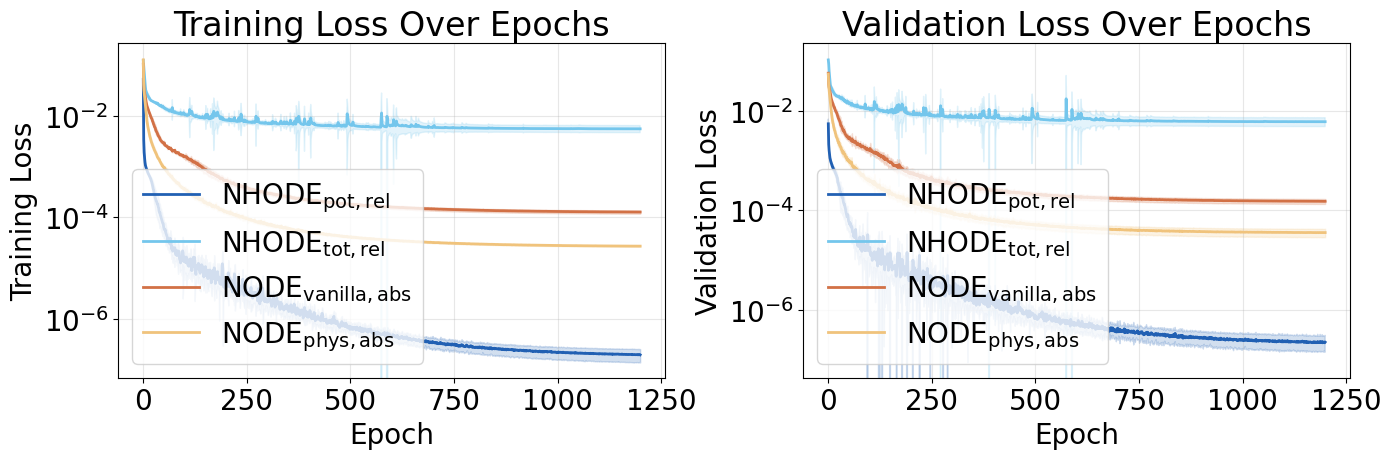

In [22]:
# Plot loss curves
plot_training_losses(
    method_to_paths,
    log_scale=True,
    save_path=None#Path("figures/training_losses.png"),
)

### 8.3 Error Over Time (Median with Percentiles)

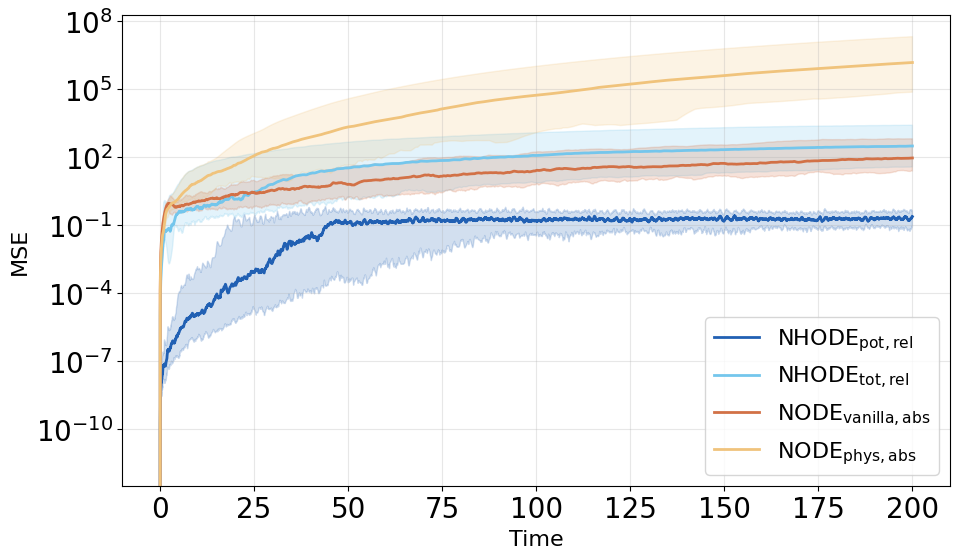

In [23]:
plot_error_over_time(
    all_metrics,
    timesteps=np.asarray(timesteps),
    use_median=True,
    log_scale=True,
    figsize=(10, 6),
    fontsize=16,
    save_path=None #Path("figures/error_over_time_median2.png"),
)

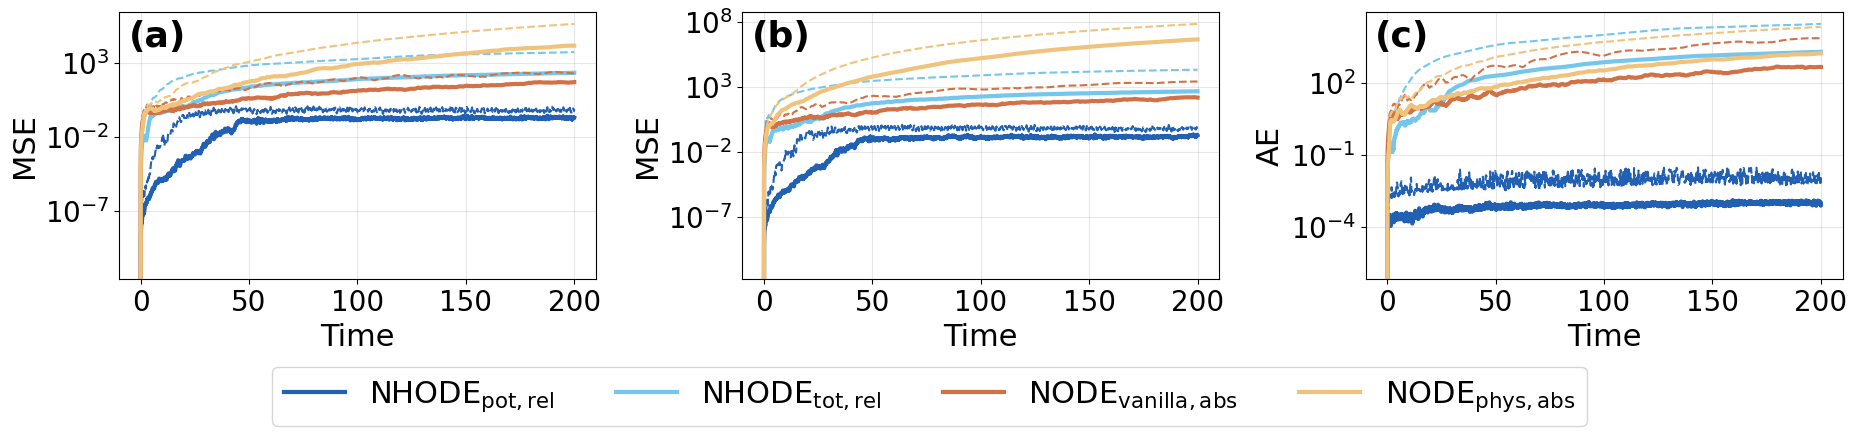

In [24]:

methods_to_plot = ["hnn_pot_rel", "hnn_tot_rel", "node_vanilla_abs", "node_phys_abs"]

predictions_to_plot= {
    method: all_predictions[method]
    for method, data in all_predictions.items() if method in methods_to_plot
}

plot_observed_vs_unobserved_vs_energy_error(
    results=predictions_to_plot,    
    times=timesteps,
    system_params=system_params,
    figsize=(19, 4),
    fontsize=22,
    save_path=None#Path("figures/observed_unobserved_energy_error_v2.pdf"),
)

### 8.4 Error Over Time (Mean with Std)

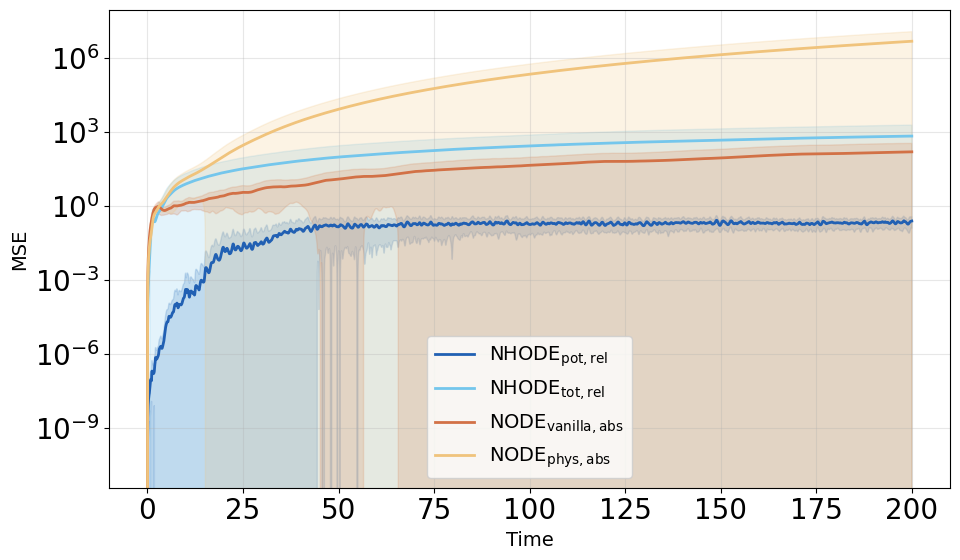

In [25]:
plot_error_over_time(
    all_metrics,
    timesteps=np.asarray(timesteps),
    use_median=False,
    log_scale=True,
    save_path=None#Path("figures/error_over_time_mean.png"),
)

### 8.5 3D Trajectory Visualization

In [26]:
def plot_snapshot_grid(
    true_traj: np.ndarray,
    predictions_dict: Dict[str, np.ndarray],
    snapshot_indices: List[int],
    timesteps: np.ndarray,
    figsize: Tuple[float, float] = (20, 16),
    save_path: Optional[Path] = None,
    fontsize: int = 14,
    xlim: Tuple[float, float] = (-0.5, 1.5),
    ylim: Tuple[float, float] = (-0.5, 1.5),
):
    """
    Plot a grid of system snapshots at specific timesteps.
    
    Rows = timesteps, Columns = True + each method.
    Each cell shows the 2D positions of the three masses with spring connections.
    
    Parameters
    ----------
    true_traj : array [T, 12]
        Ground truth trajectory
    predictions_dict : Dict[str, array [T, 12]]
        Dictionary mapping method name to predicted trajectory (mean over seeds)
    snapshot_indices : List[int]
        Timestep indices to show (rows)
    timesteps : array [T]
        Time array (for labeling)
    figsize : tuple
        Figure size
    save_path : Path or None
        If provided, save figure to this path
    fontsize : int
        Font size for labels
    xlim, ylim : tuple
        Axis limits for each subplot
    """
    import matplotlib.patches as mpatches

    methods_ordered = list(predictions_dict.keys())[::-1]
    n_rows = len(snapshot_indices)
    n_cols = 1 + len(methods_ordered)  # True + each method

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)

    # Mass colors (consistent across all subplots)
    mass_colors = ["#3D82C6", "#E19A61", "#8FE7FF"]  # red, green, blue
    spring_pairs = [(0, 1), (1, 2), (2, 0)]

    def draw_snapshot(ax, traj, t_idx, is_true=False, show_trail=True, trail_length=50):
        """Draw a single snapshot of the system at timestep t_idx."""
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.set_aspect('equal')
        ax.set_facecolor("#f8f8f8")
        ax.grid(True, alpha=0.2)
        ax.set_xticks([])
        ax.set_yticks([])

        # Draw fading tail (past trajectory), segmented for alpha gradient
        if show_trail and t_idx > 0:
            trail_start = max(0, t_idx - trail_length)
            n_trail = t_idx - trail_start
            n_segments = min(n_trail, 100)  # number of segments for fading effect

            for mass_i in range(3):
                xi = mass_i * 2
                yi = mass_i * 2 + 1

                # Split trail into segments, each progressively more opaque
                segment_indices = np.linspace(trail_start, t_idx, n_segments + 1, dtype=int)
                for seg in range(n_segments):
                    seg_alpha = 0.08 + 0.65 * (seg / n_segments)  # fade from 0.08 to 0.93
                    seg_lw = 0.8 + 10.0 * (seg / n_segments)       # thin to thick
                    i0, i1 = segment_indices[seg], segment_indices[seg + 1]
                    ax.plot(
                        traj[i0:i1+1, xi],
                        traj[i0:i1+1, yi],
                        color=mass_colors[mass_i],
                        alpha=seg_alpha,
                        linewidth=seg_lw,
                        solid_capstyle='round',
                        zorder=2,
                    )

        # Extract positions at this timestep
        pos = traj[t_idx, :6].reshape(3, 2)  # [3, 2]

        # # Draw springs between masses
        # for i, j in spring_pairs:
        #     ax.plot(
        #         [pos[i, 0], pos[j, 0]],
        #         [pos[i, 1], pos[j, 1]],
        #         color="#555555",
        #         linewidth=1.5,
        #         alpha=0.6,
        #         zorder=1,
        #     )

        # Draw masses
        for mass_i in range(3):
            ax.scatter(
                pos[mass_i, 0], pos[mass_i, 1],
                s=300,
                color=mass_colors[mass_i],
                edgecolors='black',
                linewidths=1.5,
                zorder=3,
            )

    # Column headers
    col_labels = ["True"] + [LABELS.get(m, m) for m in methods_ordered]
    for col_idx, label in enumerate(col_labels):
        axes[0, col_idx].set_title(label, fontsize=fontsize + 2, pad=10)#, fontweight='bold')

    # Row labels (time)
    for row_idx, t_idx in enumerate(snapshot_indices):
        t_val = float(timesteps[t_idx])
        axes[row_idx, 0].set_ylabel(f"t = {t_val:.1f}", fontsize=fontsize, rotation=0,
                                     labelpad=45, va='center')

    # Fill in each cell
    for row_idx, t_idx in enumerate(snapshot_indices):
        # True trajectory
        draw_snapshot(axes[row_idx, 0], true_traj, t_idx, is_true=True, show_trail=True, trail_length=400)

        # Each method
        for col_idx, method in enumerate(methods_ordered):
            pred_traj = predictions_dict[method]
            print(f"Error at time {t_idx} for method {method}: {jnp.mean((true_traj[:t_idx+1] - pred_traj[:t_idx+1])**2)}")
            draw_snapshot(axes[row_idx, col_idx + 1], pred_traj, t_idx, is_true=False, show_trail=True, trail_length=400)

    # Add a shared legend for mass colors
    labels = ["Mass 1", "Mass 2 (unobserved)", "Mass 3"]
    legend_elements = [
        plt.scatter([], [], s=150, color=mass_colors[i], edgecolors='black',
                    linewidths=1.5, label=labels[i])
        for i in range(3)
    ]
    fig.legend(
        handles=legend_elements,
        loc='lower center',
        ncol=3,
        fontsize=fontsize + 2,
        bbox_to_anchor=(0.5, -0.06),
        framealpha=0.9,
    )

    #plt.suptitle("System Snapshots Over Time", fontsize=fontsize + 4, y=1.01)
    plt.tight_layout()

    # Draw a single black frame around the entire left (ground truth) column
    col0_bboxes = [axes[r, 0].get_position() for r in range(n_rows)]
    pad = 0 #0.004
    rx0 = min(b.x0 for b in col0_bboxes) - pad
    ry0 = min(b.y0 for b in col0_bboxes) - pad
    rx1 = max(b.x1 for b in col0_bboxes) + pad
    ry1 = max(b.y1 for b in col0_bboxes) + pad
    rect = mpatches.Rectangle(
        (rx0, ry0), rx1 - rx0, ry1 - ry0,
        linewidth=5,
        edgecolor='black',
        facecolor='none',
        transform=fig.transFigure,
        clip_on=False,
        zorder=10,
    )
    fig.add_artist(rect)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()


In [27]:
for method, pred_data in all_predictions.items():
    print(f"Method: {method}")
    print(f"  Mean prediction shape: {pred_data['mean_prediction'].shape}")
    print(f"  Std prediction shape: {pred_data['std_prediction'].shape}")

Method: hnn_pot_rel
  Mean prediction shape: (10, 20001, 18)
  Std prediction shape: (10, 20001, 18)
Method: hnn_tot_rel
  Mean prediction shape: (10, 20001, 18)
  Std prediction shape: (10, 20001, 18)
Method: node_vanilla_abs
  Mean prediction shape: (10, 20001, 18)
  Std prediction shape: (10, 20001, 18)
Method: node_phys_abs
  Mean prediction shape: (10, 20001, 18)
  Std prediction shape: (10, 20001, 18)


dict_keys(['hnn_pot_rel', 'hnn_tot_rel', 'node_vanilla_abs', 'node_phys_abs'])
Error at time 100 for method node_phys_abs: 0.01892470382153988
Error at time 100 for method node_vanilla_abs: 0.04184515029191971
Error at time 100 for method hnn_tot_rel: 0.014968686737120152
Error at time 100 for method hnn_pot_rel: 1.4283949134608065e-08
Error at time 500 for method node_phys_abs: 0.6329370737075806
Error at time 500 for method node_vanilla_abs: 0.3953728973865509
Error at time 500 for method hnn_tot_rel: 0.17610791325569153
Error at time 500 for method hnn_pot_rel: 6.676066277577775e-06
Error at time 1000 for method node_phys_abs: 2.721708297729492
Error at time 1000 for method node_vanilla_abs: 0.42868903279304504
Error at time 1000 for method hnn_tot_rel: 0.6023989915847778
Error at time 1000 for method hnn_pot_rel: 0.0001899370108731091
Error at time 1500 for method node_phys_abs: 4.459539413452148
Error at time 1500 for method node_vanilla_abs: 0.42844319343566895
Error at time 1500

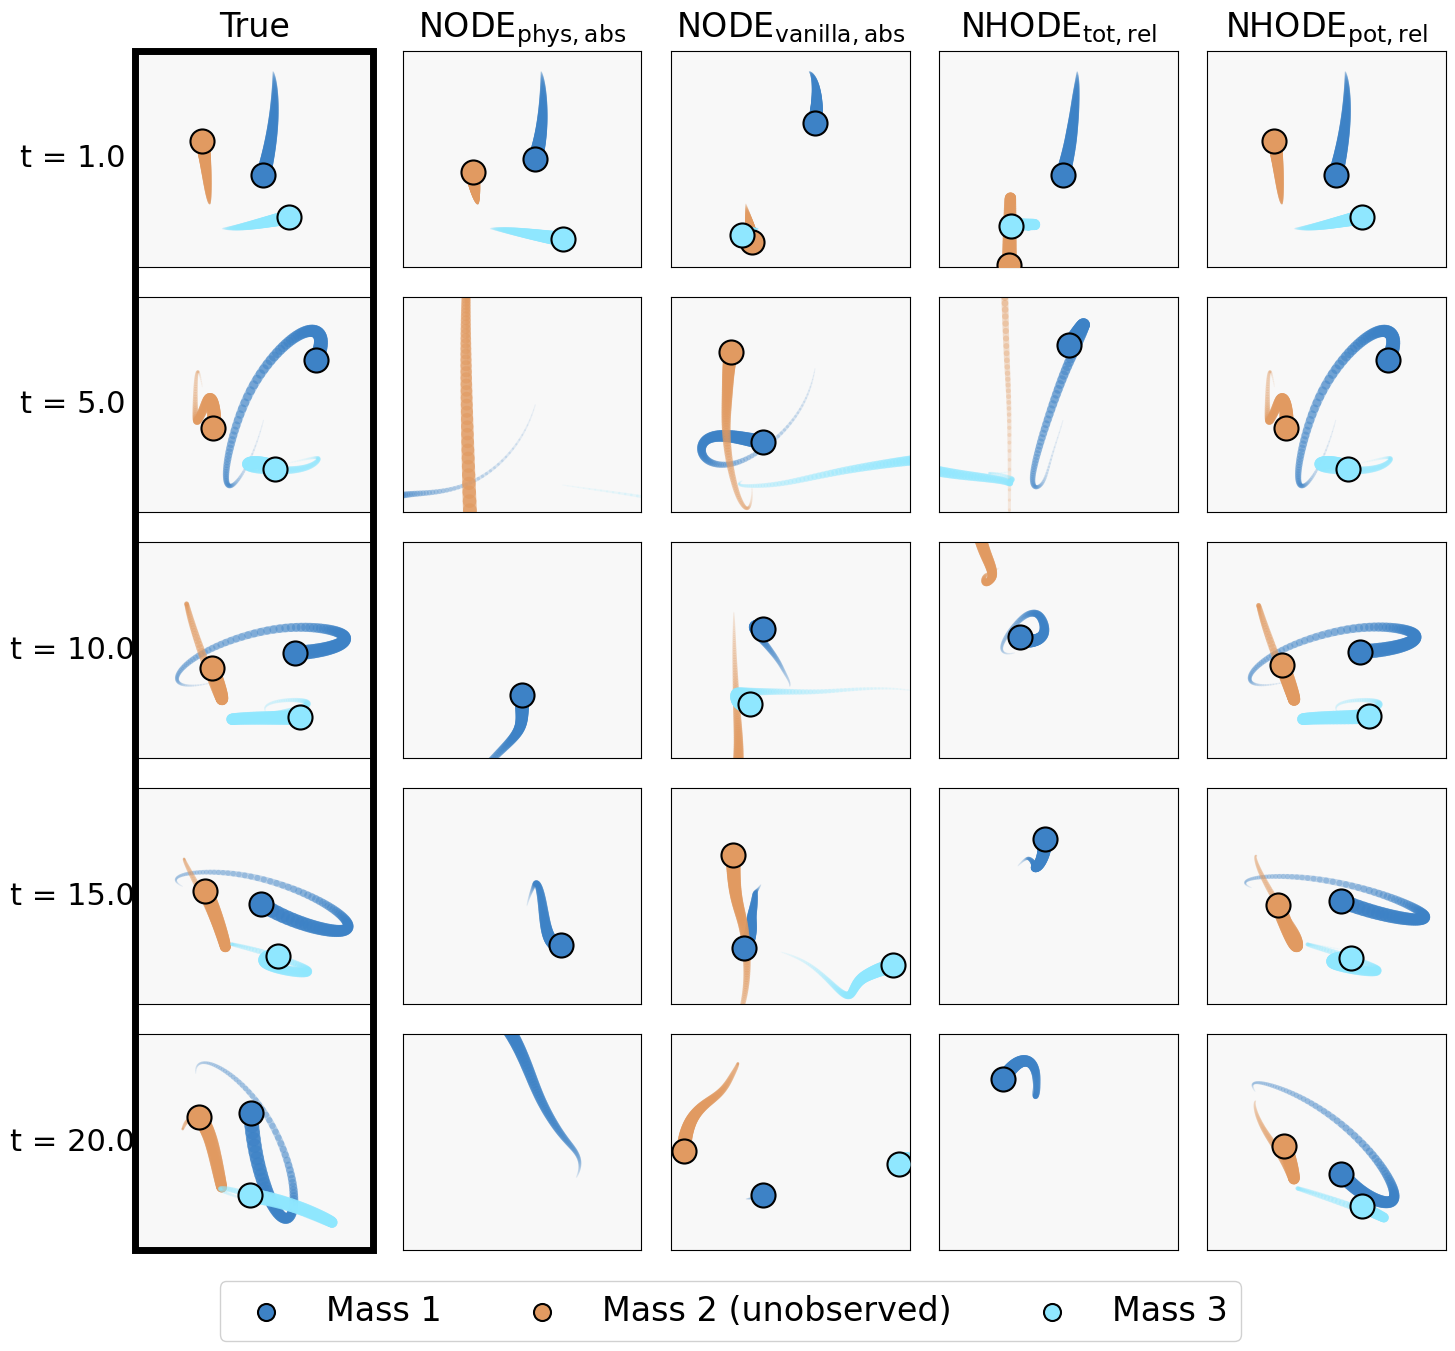

In [28]:
# Choose snapshot timestep indices (evenly spaced or hand-picked)
snapshot_indices = [100, 500, 1000, 1500, 2000]      # Used in paper
#snapshot_indices = [50, 500, 1000, 1500, 2000, 2999] 
#snapshot_indices = [100, 500, 1000, 2500, 5000, 7500, 10000, 12500,15000, 17500, 20000] 

methods_to_plot = ["hnn_pot_rel", "hnn_tot_rel", "node_vanilla_abs", "node_phys_abs"]
# Use mean predictions for a single IC
ic_idx = 5

predictions_for_snapshot = {
    method: np.asarray(pred_data['mean_prediction'][ic_idx])
    for method, pred_data in all_predictions.items() if method in methods_to_plot
}

print(predictions_for_snapshot.keys())

plot_snapshot_grid(
    true_traj=np.asarray(true_trajectories[ic_idx]),
    predictions_dict=predictions_for_snapshot,
    snapshot_indices=snapshot_indices,
    timesteps=np.asarray(timesteps),
    figsize=(15, 13),  #paper figsize
    #figsize=(10, 20), #superlong rollout
    fontsize=22,
    xlim=(-0.6, 1.5),
    ylim=(-0.4, 1.5),
    # xlim=(-1.0, 2.0),
    # ylim=(-1.0, 2.0),
    save_path=None#Path("figures/snapshot_grid_without_t0_v2.pdf")
)

/var/folders/63/lsr6bh597y9gd6cc0mp34_jh0000gn/T/ipykernel_66714/3441159253.py:140: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()   # stabilise positions before reading bboxes


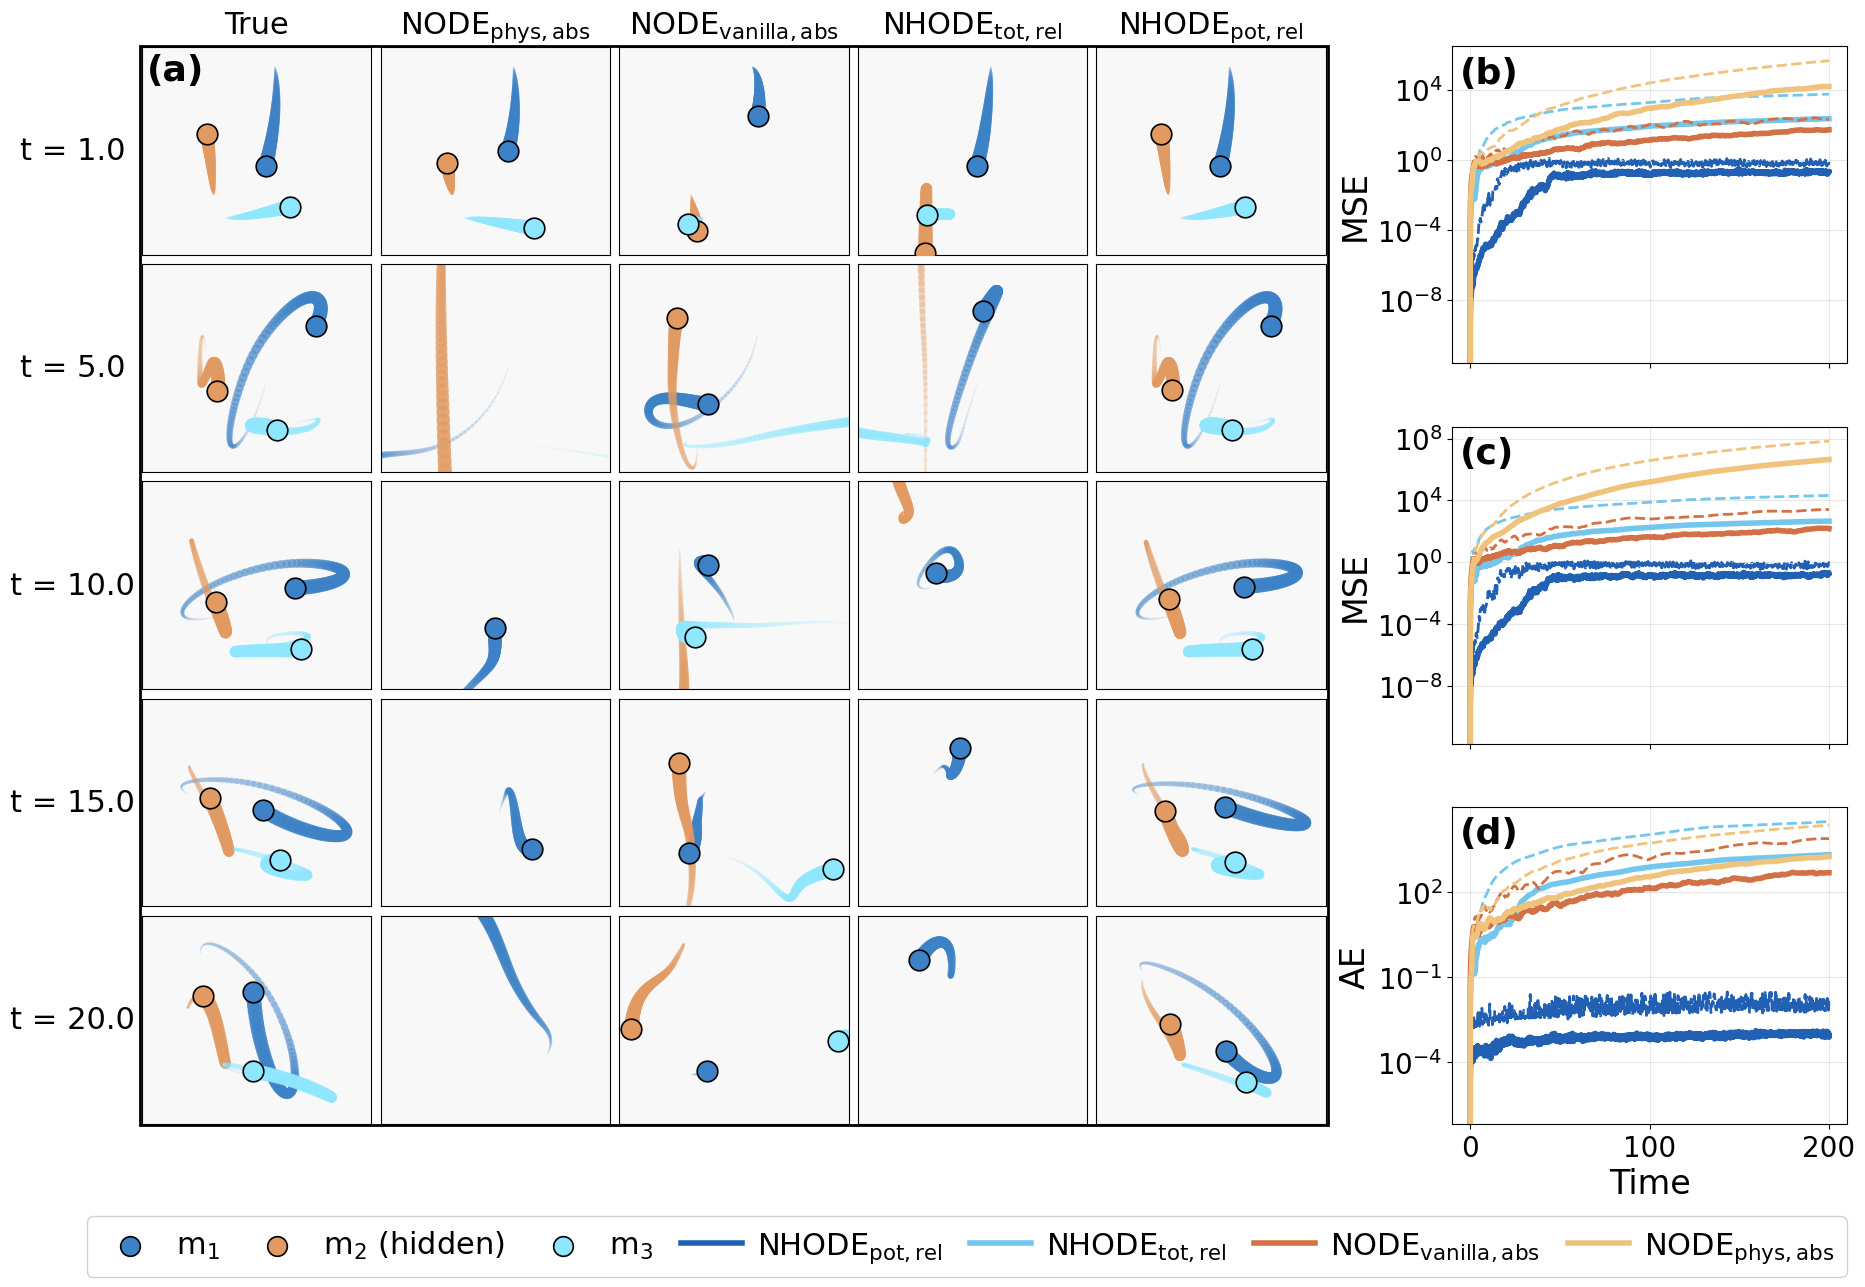

In [29]:
# ic_idx and snapshot_indices, predictions_for_snapshot already defined above
error_trajectories = {m: all_predictions[m] for m in methods_to_plot}

plot_combined_snapshot_and_errors(
    true_traj=np.asarray(true_trajectories[ic_idx]),
    predictions_dict=predictions_for_snapshot,
    all_trajectories=error_trajectories,
    snapshot_indices=snapshot_indices,
    timesteps=np.asarray(timesteps),
    system_params=system_params,
    figsize=(22, 14),
    snapshot_width_ratio=0.75,
    fontsize=24,
    xlim=(-0.6, 1.5),
    ylim=(-0.4, 1.5),
    trail_length=400,
    col_wspace=0.16,   # increase this for more room around right-column y-labels
    #save_path=Path('figures/combined_snapshot_and_errors.pdf'),
)

In [30]:
# Choose a test trajectory to visualize
ic_idx = 0

# Extract mean predictions for this IC
predictions_for_plot = {
    method: np.asarray(pred_data['mean_prediction'][ic_idx])
    for method, pred_data in all_predictions.items() if method in methods_to_plot
}

# Plot each body
# for body_idx in range(3):
#     plot_3d_trajectory(
#         true_traj=np.asarray(true_trajectories[ic_idx]),
#         predictions_dict=predictions_for_plot,
#         body_idx=body_idx,
#         save_path=None#Path(f"figures/3d_trajectory_body{body_idx}_ic{ic_idx}.png"),
#     )

### 8.6 1D Trajectory Comparison

/var/folders/63/lsr6bh597y9gd6cc0mp34_jh0000gn/T/ipykernel_66714/1000613565.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


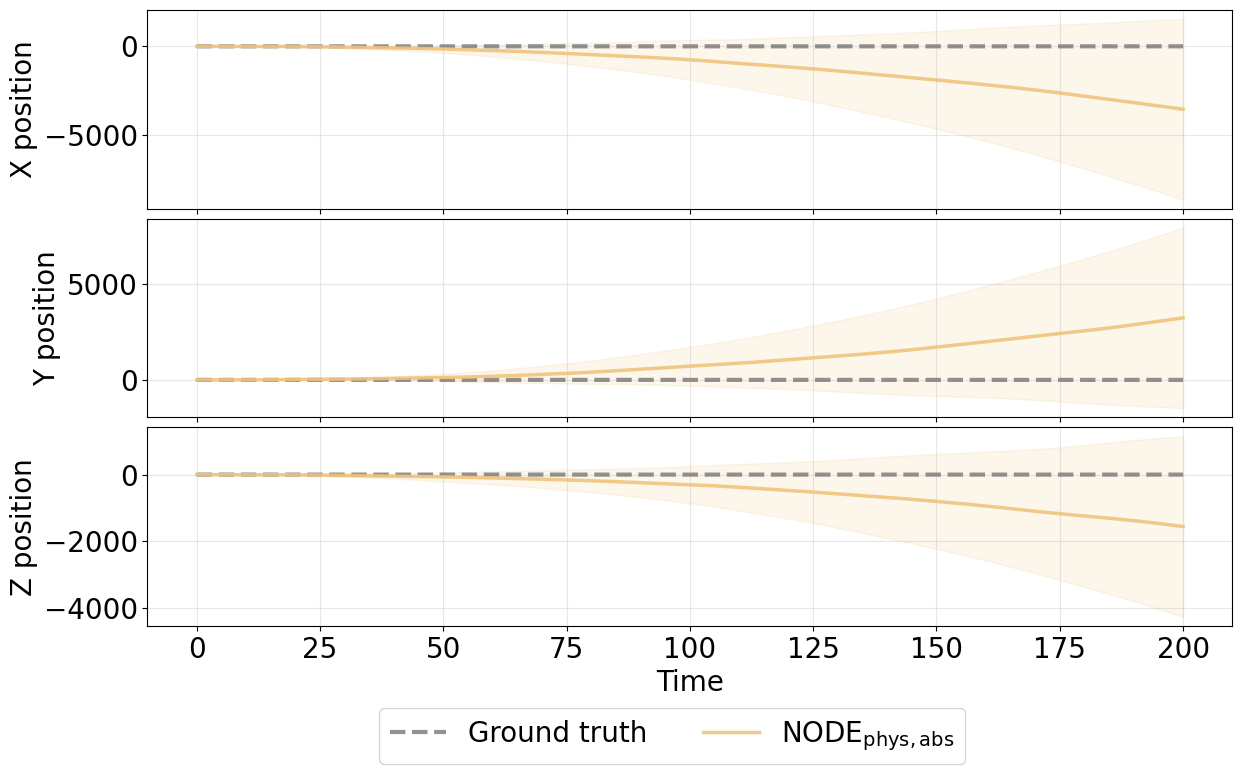

In [ ]:
# Choose IC and body
ic_idx = 0
body_idx = 1


#methods_to_plot = ["hnn_pot_rel", "hnn_tot_rel", "node_vanilla_abs", "node_phys_abs"]
methods_to_plot = ["node_phys_abs"]
                   
# Extract predictions with std for this IC
predictions_1d = {
    method: {
        'mean_prediction': np.asarray(pred_data['mean_prediction'][ic_idx]),
        'std_prediction': np.asarray(pred_data['std_prediction'][ic_idx]),
    }
    for method, pred_data in all_predictions.items() if method in methods_to_plot
}

# Plot all three coordinates stacked vertically in one figure.
# stride=10 downsamples 20001 → 2001 points, keeping rendering fast.
plot_1d_trajectory(
    true_traj=np.asarray(true_trajectories[ic_idx]),
    predictions_dict=predictions_1d,
    timesteps=np.asarray(timesteps),
    body_idx=body_idx,
    coords=['x', 'y', 'z'],
    show_std=True,
    stride=10,
    fontsize=20,
    figsize=(14, 8),
    save_path=None#f"figures/superlong_rollouts/node_phys_abs_rollout.pdf",
)


/var/folders/63/lsr6bh597y9gd6cc0mp34_jh0000gn/T/ipykernel_66714/4248792966.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


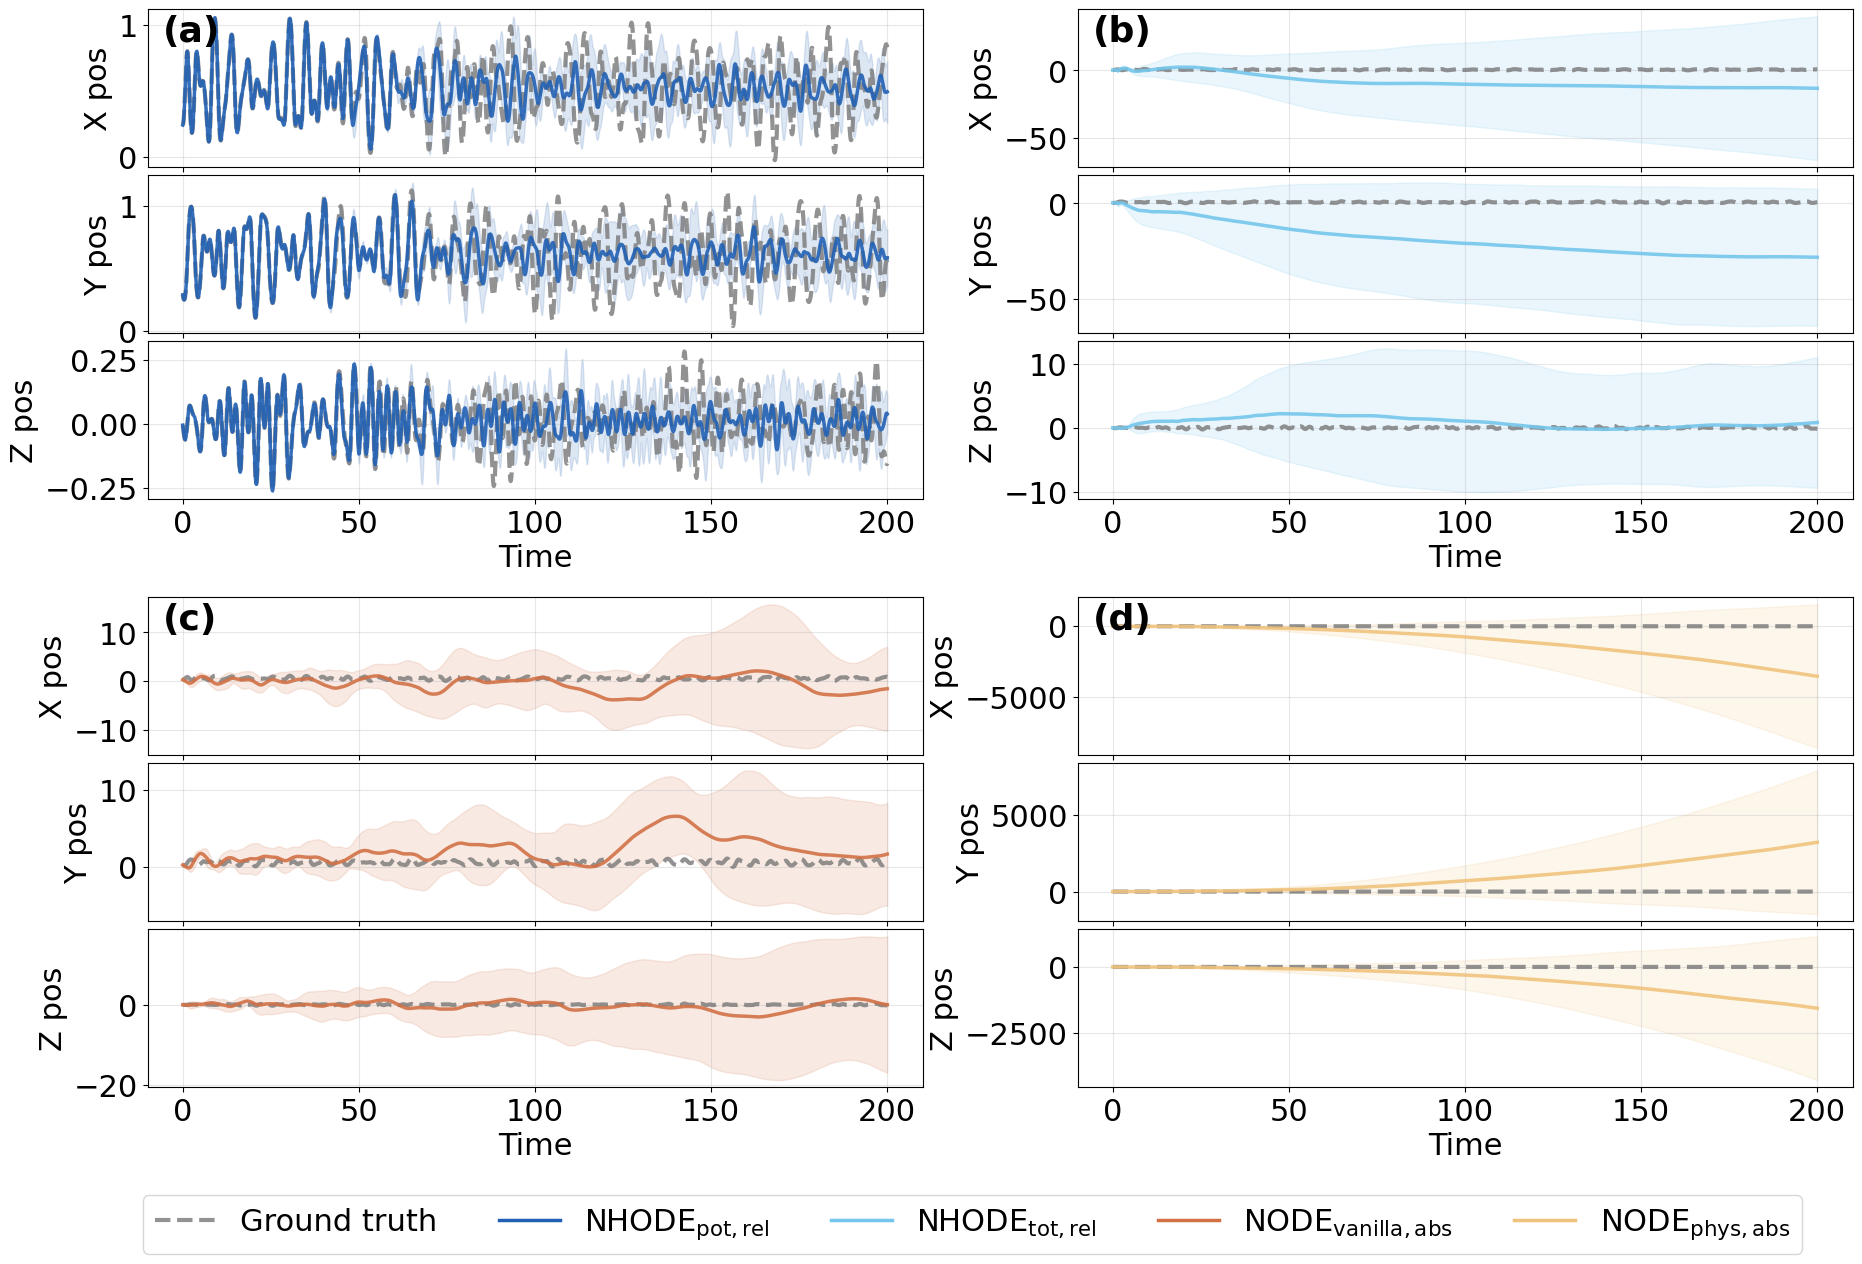

In [ ]:
methods_to_plot_1d = ["hnn_pot_rel", "hnn_tot_rel", "node_vanilla_abs", "node_phys_abs"]

predictions_1d_grid = {
    method: {
        'mean_prediction': np.asarray(all_predictions[method]['mean_prediction'][ic_idx]),
        'std_prediction':  np.asarray(all_predictions[method]['std_prediction'][ic_idx]),
    }
    for method in methods_to_plot_1d if method in all_predictions
}

plt.rcParams['font.size'] = 22

plot_1d_trajectory_grid(
    true_traj=np.asarray(true_trajectories[ic_idx]),
    predictions_dict=predictions_1d_grid,
    timesteps=np.asarray(timesteps),
    body_idx=body_idx,
    coords=['x', 'y', 'z'],
    show_std=True,
    stride=10,
    fontsize=22,
    figsize=(22, 14),
    save_path=None#"figures/superlong_rollouts/all_methods_rollout_grid.pdf",
)


### 8.7 Analyze Multiple Rollout Lengths

In [35]:
def analyze_rollout_lengths(
    rollout_lengths: List[int],
    method_to_paths: Dict[str, List[Path]],
    y0_batch: jnp.ndarray,
    system_params: Params,
    epsilon: float,
    t_final: float = 10.0,
    eval_dims: Optional[jnp.ndarray] = None,
) -> Dict[int, List[ErrorMetrics]]:
    """
    Evaluate cumulative errors for different rollout lengths.
    
    Returns
    -------
    results : Dict[int, List[ErrorMetrics]]
        Mapping from rollout length to list of metrics for each method
    """
    results = {}
    
    for n_steps in rollout_lengths:
        print(f"\n{'='*50}")
        print(f"Rollout length: {n_steps} steps")
        print(f"{'='*50}")
        
        # Create timesteps for this rollout length
        ts = jnp.linspace(0, t_final, n_steps)
        
        # Compute ground truth
        integrator_true = integrate_vector_field(
            ts, term=vector_field_three_body_plummer, eps=epsilon
        )
        true_trajs = integrator_true(None, system_params, y0_batch)
        
        # Evaluate each method
        metrics_list = []
        for method, seed_dirs in method_to_paths.items():
            print(f"  {method}...", end=" ")
            key_local = jax.random.PRNGKey(42)
            metrics, _ = evaluate_method(
                method=method,
                seed_dirs=seed_dirs,
                y0_batch=y0_batch,
                true_trajectories=true_trajs,
                timesteps=ts,
                system_params=system_params,
                epsilon=epsilon,
                eval_dims=eval_dims,
                key=key_local,
            )
            metrics_list.append(metrics)
            print(f"cum_mean = {metrics.cum_mean:.6e}")
        
        results[n_steps] = metrics_list
    
    return results


def plot_cumulative_error_vs_rollout(
    results: Dict[int, List[ErrorMetrics]],
    figsize: Tuple[float, float] = (10, 6),
    save_path: Optional[Path] = None,
):
    """
    Plot cumulative error as a function of rollout length.
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Organize data by method
    rollout_lengths = sorted(results.keys())
    methods = [m.method for m in results[rollout_lengths[0]]]
    
    for method in methods:
        means = []
        stds = []
        
        for n_steps in rollout_lengths:
            metrics = next(m for m in results[n_steps] if m.method == method)
            means.append(metrics.cum_mean)
            stds.append(metrics.cum_std)
        
        means = np.array(means)
        stds = np.array(stds)
        
        color = COLORS.get(method, "black")
        label = LABELS.get(method, method)
        
        ax.plot(rollout_lengths, means, 'o-', label=label, color=color, linewidth=2, markersize=8)
        ax.fill_between(rollout_lengths, means - stds, means + stds, alpha=0.2, color=color)
    
    ax.set_xlabel('Number of Timesteps')
    ax.set_ylabel('Cumulative MSE')
    ax.set_title('Cumulative Error vs Rollout Length')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()

In [36]:
# Analyze different rollout lengths
rollout_lengths = [100, 250, 500, 1000, 2000]

rollout_results = analyze_rollout_lengths(
    rollout_lengths=rollout_lengths,
    method_to_paths=method_to_paths,
    y0_batch=y0_batch,
    system_params=system_params,
    epsilon=EPSILON,
    t_final=T_FINAL,
    eval_dims=eval_dims,
)

# Plot results
plot_cumulative_error_vs_rollout(
    rollout_results,
    save_path=Path("figures/cumulative_error_vs_rollout.png"),
)


Rollout length: 100 steps
  hnn_pot_rel... 

KeyboardInterrupt: 

## 9. Custom Analysis

Add your own analysis cells here!